# Hola &#x1F600;,

Soy **Hesus Garcia** – **"Soy el único Hesus que conoces (y probablemente conocerás) 🌟"** – Sí, como "Jesús", pero con una H que me hace único. Puede sonar raro, pero créeme, ¡no lo olvidarás! Como tu revisor en Triple-Ten, estoy aquí para guiarte y ayudarte a mejorar tu código. Si algo necesita un ajuste, no hay de qué preocuparse; ¡aquí estoy para hacer que tu trabajo brille con todo su potencial! ✨

Cada vez que encuentre un detalle importante en tu código, te lo señalaré para que puedas corregirlo y así te prepares para un ambiente de trabajo real, donde el líder de tu equipo actuaría de manera similar. Si en algún momento no logras solucionar el problema, te daré más detalles para ayudarte en nuestra próxima oportunidad de revisión.

Es importante que cuando encuentres un comentario, **no los muevas, no los modifiques, ni los borres**.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> - ¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis de datos o al proyecto. Continúa aplicando estas buenas prácticas en futuras secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Este código está correcto, pero se puede optimizar. Considera implementar mejoras para que sea más eficiente y fácil de leer. Esto fortalecerá la calidad de tu proyecto.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error en el código que es necesario corregir para aprobar esta sección. Por favor, revisa y corrige este punto, ya que es fundamental para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto.
- **Áreas de mejora:** Sugerencias sobre aspectos donde puedes mejorar.
- **Temas adicionales para investigar:** Ideas de temas opcionales que puedes explorar por tu cuenta para desarrollar aún más tus habilidades.

Estos temas adicionales no son obligatorios en esta etapa, pero pueden serte útiles para profundizar en el futuro.

---


Esta estructura en viñetas facilita la lectura y comprensión de cada parte del comentario final.

También puedes responderme de la siguiente manera si tienes alguna duda o quieres aclarar algo específico:


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>


**¡Empecemos!** &#x1F680;


# PROYECTO SPRINT 9

## Objetivos del proyecto

Investigar y analizar:
+ Cómo los clientes usan el servicio
+ Cuándo empiezan a comprar
+ Cuánto dinero aporta cada cliente a la compañía
+ Cuándo los ingresos cubren el costo de adquisición de los clientes.

## Análisis exploratorio

### Paso 1: Acceder los datos y prepararlos para el análisis

#### Importar librerías y leer archivos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visits= pd.read_csv("/datasets/visits_log_us.csv")
visits.sample(5)

,Device,End Ts,Source Id,Start Ts,Uid
76963,desktop,2017-09-11 16:22:00,9,2017-09-11 15:55:00,18395739947456487672
262681,desktop,2017-12-15 20:35:00,9,2017-12-15 20:34:00,11022766666822512981
154951,touch,2018-03-19 20:35:00,5,2018-03-19 20:30:00,5410003609707328404
165055,touch,2017-10-30 11:34:00,2,2017-10-30 11:33:00,16994662237718602679
138769,touch,2018-03-26 18:10:00,4,2018-03-26 17:52:00,5989942620891714912


In [3]:
#Cambio de nombres de columnas para evitar uso de mayúsculas
visits.columns= ["device", "end_ts", "source_id", "start_ts", "uid"]

In [4]:
orders= pd.read_csv("/datasets/orders_log_us.csv")
orders.sample(5)

,Buy Ts,Revenue,Uid
9571,2017-09-28 23:57:00,0.33,13486014841579728464
16322,2017-11-06 10:18:00,1.83,9952410608049761025
46437,2018-05-05 18:06:00,24.44,2506978395402867576
9276,2017-09-27 10:59:00,3.67,13100852082721789019
28000,2018-01-04 11:55:00,1.83,10959471280035462607


In [5]:
#Cambio de nombres de columnas para evitar uso de mayúsculas
orders.columns= ["buy_ts", "revenue", "uid"]

In [6]:
costs= pd.read_csv("/datasets/costs_us.csv")
costs.sample(5)

,source_id,dt,costs
799,3,2017-08-13,179.91
1867,9,2017-07-22,7.29
559,2,2017-12-14,213.38
1164,4,2017-08-15,210.60
1428,4,2018-05-08,132.93


#### Corrección de tipos de datos 

In [7]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   device     359400 non-null  object
 1   end_ts     359400 non-null  object
 2   source_id  359400 non-null  int64 
 3   start_ts   359400 non-null  object
 4   uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   buy_ts   50415 non-null  object 
 1   revenue  50415 non-null  float64
 2   uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [9]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


Se requiere cambiar el tipo de dato en las columnas en donde se manejan valores de fecha, tal es el caso de "end_ts", "start_ts", "buy_ts" y "dt". Las columnas mencionadas anteriormente son de tipo *object* y serán convertidas a *datetime*

In [10]:
visits["end_ts"]= pd.to_datetime(visits["end_ts"])
visits["end_ts"].head()

0   2017-12-20 17:38:00
1   2018-02-19 17:21:00
2   2017-07-01 01:54:00
3   2018-05-20 11:23:00
4   2017-12-27 14:06:00
Name: end_ts, dtype: datetime64[ns]

In [11]:
visits["start_ts"]= pd.to_datetime(visits["start_ts"])
visits["start_ts"].head()

0   2017-12-20 17:20:00
1   2018-02-19 16:53:00
2   2017-07-01 01:54:00
3   2018-05-20 10:59:00
4   2017-12-27 14:06:00
Name: start_ts, dtype: datetime64[ns]

In [12]:
orders["buy_ts"]= pd.to_datetime(orders["buy_ts"])
orders["buy_ts"].head()

0   2017-06-01 00:10:00
1   2017-06-01 00:25:00
2   2017-06-01 00:27:00
3   2017-06-01 00:29:00
4   2017-06-01 07:58:00
Name: buy_ts, dtype: datetime64[ns]

In [13]:
costs["dt"]= pd.to_datetime(costs["dt"])
costs["dt"].head()

0   2017-06-01
1   2017-06-02
2   2017-06-03
3   2017-06-04
4   2017-06-05
Name: dt, dtype: datetime64[ns]

#### Detectar filas totalmente duplicadas

In [14]:
print("Filas totalmente duplicadas en visits:", visits.duplicated().sum())
print("Filas totalmente duplicadas en orders:", orders.duplicated().sum())
print("Filas totalmente duplicadas en costs:", costs.duplicated().sum())

Filas totalmente duplicadas en visits: 0
Filas totalmente duplicadas en orders: 0
Filas totalmente duplicadas en costs: 0


No se encontraron filas totalmente duplicadas en ninguno de los 3 datasets. Podemos proceder al análisis.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Muy buen inicio en la preparación de los datos: la importación de librerías, la lectura de archivos y la conversión de tipos de datos se realizaron correctamente. Este orden en la limpieza facilitará el análisis exploratorio posterior. </div>


### Paso 2: Análisis de datos

#### Métricas de "Visitas"

**Objetivo:** Detectar patrones de visita al servidor Showz en diferentes períodos de tiempo (mes, semana, día).

**1. ¿Cuántas personas lo usan cada día, semana y mes?**

In [15]:
#Extraer el año, mes, semana, día y fecha sin hora de la columna start_ts
visits['visits_year']  = visits['start_ts'].dt.isocalendar().year
visits['visits_month'] = visits['start_ts'].dt.month
visits['visits_week']  = visits['start_ts'].dt.isocalendar().week
visits['visits_day']  = visits['start_ts'].dt.day
visits['visits_date']  = visits['start_ts'].dt.date
visits.sample(5)

,device,end_ts,source_id,start_ts,uid,visits_year,visits_month,visits_week,visits_day,visits_date
105314,desktop,2017-10-23 20:31:00,5,2017-10-23 20:17:00,12409367131114807264,2017,10,43,23,2017-10-23
98999,desktop,2017-12-10 21:28:00,5,2017-12-10 21:24:00,13897354777351891739,2017,12,49,10,2017-12-10
114093,desktop,2017-09-08 08:55:00,4,2017-09-08 08:54:00,18287164123683589659,2017,9,36,8,2017-09-08
302758,desktop,2017-12-01 12:07:00,1,2017-12-01 11:50:00,4303189661459880651,2017,12,48,1,2017-12-01
162299,desktop,2017-12-03 09:55:00,2,2017-12-03 09:49:00,10218622300192155814,2017,12,48,3,2017-12-03


In [16]:
visits_grouped= visits.groupby("visits_year")["visits_month"].unique()
visits_grouped

visits_year
2017    [12, 7, 9, 11, 6, 10, 8]
2018             [2, 5, 1, 4, 3]
Name: visits_month, dtype: object

Cabe destacar que los datos sobre las visitas comprenden el período de Junio 2017 a Mayo 2018.

**Usuarios únicos activos al día (DAU)**

In [17]:
dau_total = visits.groupby("visits_date").agg({"uid": "nunique"}).reset_index()
dau_total.columns= ("visits_date", "daily_users")
dau_total.head()

,visits_date,daily_users
0,2017-06-01,605
1,2017-06-02,608
2,2017-06-03,445
3,2017-06-04,476
4,2017-06-05,820


In [18]:
dau_total["daily_users"].describe()

count     364.000000
mean      907.991758
std       370.513838
min         1.000000
25%       594.000000
50%       921.000000
75%      1173.000000
max      3319.000000
Name: daily_users, dtype: float64

+ Se puede observar que en promedio existen **908 usuarios por día**
+ El mínimo es de **1 usuario al día**, mientras que el máximo fue de **3,319 usuarios al día.**
+ Cabe mencionar que los valores mínimo y máximo se encuentran muy alejados de la mediana que es de **921 usuarios al día** sin embargo no los eliminaré ya que podrían tratarse de casos reales y no de errores.

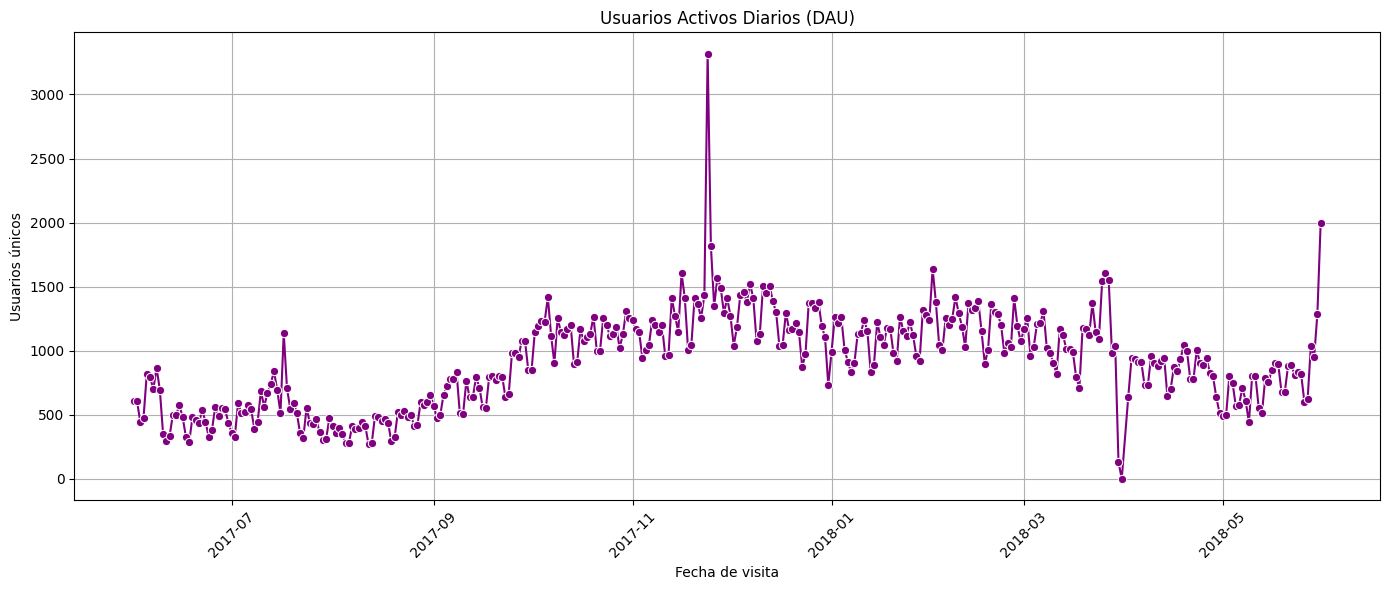

In [19]:
# Crear gráfico de línea
plt.figure(figsize=(14, 6))
sns.lineplot(data=dau_total, x='visits_date', y='daily_users', 
             marker='o', color= "purple")

plt.title('Usuarios Activos Diarios (DAU)')
plt.xlabel('Fecha de visita')
plt.ylabel('Usuarios únicos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)

plt.show()

+ Al graficar los datos anteriores se pueden observar claramente los outliers. Siendo el pico máximo a finales de Noviembre del 2017 y el mínimo a finales del mes de Marzo del 2018.
  
+ Se observa un incremento de visitas al día en el período comprendido entre finales de Septiembre 2017 hasta mediados de Marzo 2018.

**Usuarios únicos activos semanales (WAU)**

In [20]:
wau_total = visits.groupby(["visits_year", "visits_week"]).agg({"uid": "nunique"}).reset_index()
wau_total.columns= ("visits_year", "visits_week", "weekly_users")
wau_total.head()

,visits_year,visits_week,weekly_users
0,2017,22,2021
1,2017,23,4129
2,2017,24,2812
3,2017,25,2878
4,2017,26,3064


In [21]:
wau_total["weekly_users"].describe()

count       53.000000
mean      5716.245283
std       2049.898027
min       2021.000000
25%       4128.000000
50%       5740.000000
75%       7401.000000
max      10586.000000
Name: weekly_users, dtype: float64

* Al agrupar los datos por año y semana, se puede observar que en promedio existen **5,716 usuarios en una semana.**
* El valor mínimo de usuarios en una semana fue de **2,021 usuarios**, mientras que el máximo fue de **10,586 usuarios.**

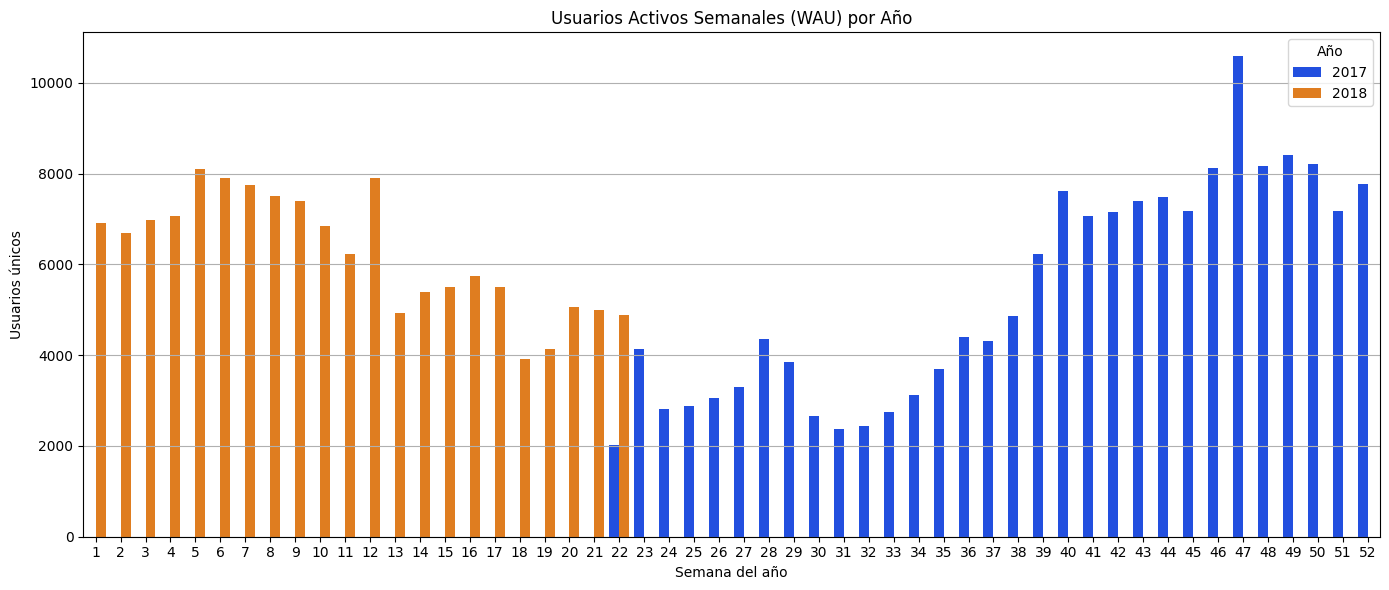

In [22]:
# Crear gráfico de barras
plt.figure(figsize= (14, 6))
sns.barplot(data= wau_total,
    x='visits_week',
    y='weekly_users',
    hue='visits_year',
    palette='bright')

plt.title('Usuarios Activos Semanales (WAU) por Año')
plt.xlabel('Semana del año')
plt.ylabel('Usuarios únicos')
plt.legend(title='Año')
plt.tight_layout()
plt.grid(axis='y')

plt.show()

* De acuerdo al gráfico anterior se observa que la semana donde se registraron más visitas fue en la **semana 47 del año 2017**, con un registro de más de 10,000 visitas.
  
* Las semanas en donde hubo un descenso en el uso del servicio fueron entre las **semanas 31 y 32 del año 2017** con un registro de menos de 2,500 visitas.

* Durante la mitad del año (50% de las semanas) se observa un flujo constante de 5,700 visitas por semana.

**Usuarios únicos activos mensuales (MAU)**

In [23]:
mau_total = visits.groupby(["visits_year", "visits_month"]).agg({"uid": "nunique"}).reset_index()
mau_total.columns= ("visits_year", "visits_month", "monthly_users")
mau_total.head()

,visits_year,visits_month,monthly_users
0,2017,6,13259
1,2017,7,14183
2,2017,8,11631
3,2017,9,18975
4,2017,10,29692


In [24]:
mau_total["monthly_users"].describe()

count       12.000000
mean     23228.416667
std       7546.380462
min      11631.000000
25%      17777.000000
50%      24240.500000
75%      28984.750000
max      32797.000000
Name: monthly_users, dtype: float64

+ Al agrupar los datos por año y mes, se puede observar que en promedio existen **23,228 usuarios** en un mes.
+ El valor mínimo en un mes fue de **11,631 usuarios**, mientras que el máximo fue de **32,797 usuarios.**

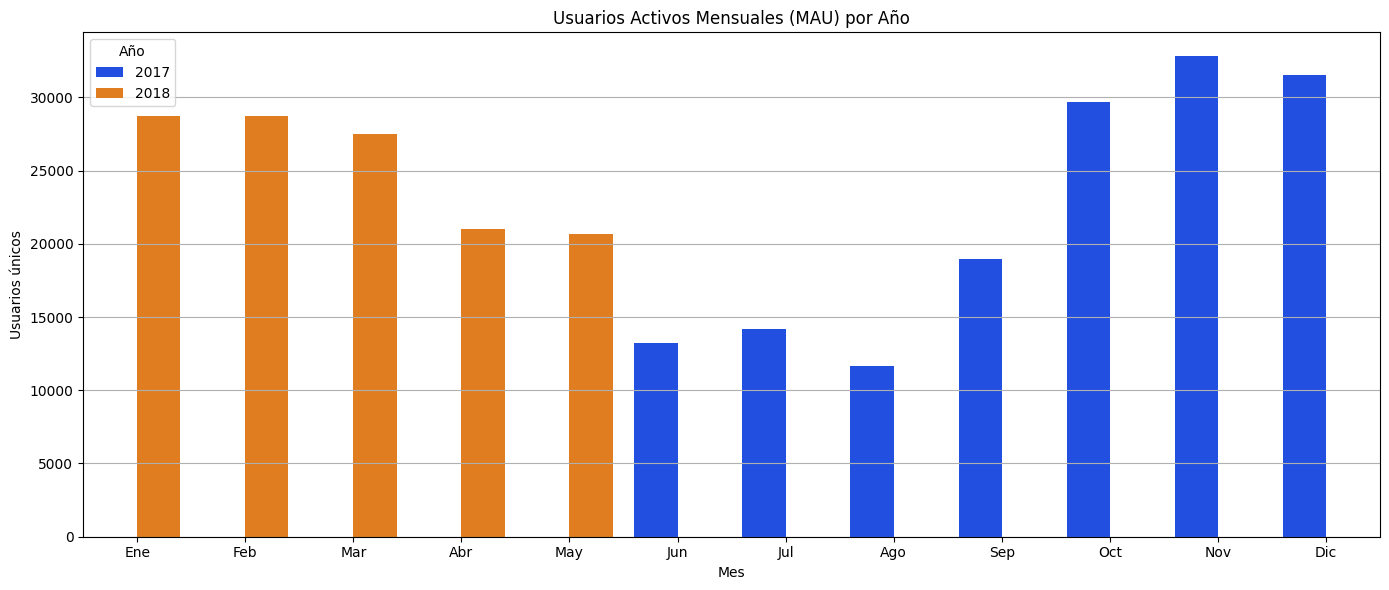

In [25]:
# Gráfico de barras
plt.figure(figsize=(14, 6))
sns.barplot(data=mau_total,
    x='visits_month',
    y='monthly_users',
    hue='visits_year',
    palette='bright')

plt.title('Usuarios Activos Mensuales (MAU) por Año')
plt.xlabel('Mes')
plt.ylabel('Usuarios únicos')
plt.xticks(ticks=range(0, 12), labels=[
    'Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
    'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend(title='Año')
plt.grid(axis='y')
plt.tight_layout()

plt.show()

* De acuerdo al gráfico anterior, se observa que la mayor cantidad de visitas al mes sucedieron en los meses de **Noviembre y Diciembre del año 2017,** con un registro de más de 30,000 visitas.
* Durante el mes de **Agosto del año 2017** se observó un descenso en el uso del servicio, con un total de apenas 11,631 visitas.
* Durante el **año 2018** el número de visitas durante **los 3 primeros meses** se mantuvo constante, alrededor de 25,000 visitas.
* Lo anterior muestra un comportamiento estacional, siendo más fuerte a finales y principios del año y después desciende durante los meses de Junio, Julio y Agosto.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Excelente manejo de métricas de usuarios activos (DAU, WAU, MAU) acompañado de descripciones claras y gráficas bien interpretadas. El análisis refleja comprensión del comportamiento estacional y da solidez al estudio. </div>


**2. Sesiones por día**

In [26]:
#Calcular sesiones diarias totales y únicas por usuario
sessions_per_user_day = visits.groupby("visits_date").agg({"uid": ["count", "nunique"]})

sessions_per_user_day.columns = ["n_sessions", "n_users"]

# Calcular el número de sesiones promedio por usuario en cada día
sessions_per_user_day["mean_sessions"] = (
    sessions_per_user_day['n_sessions'] / sessions_per_user_day['n_users']
)

sessions_per_user_day.round(2).head()

,n_sessions,n_users,mean_sessions
visits_date,,,
2017-06-01,664,605,1.10
2017-06-02,658,608,1.08
2017-06-03,477,445,1.07
2017-06-04,510,476,1.07
2017-06-05,893,820,1.09


In [27]:
sessions_per_user_day.describe()

,n_sessions,n_users,mean_sessions
count,364.000000,364.000000,364.000000
mean,987.362637,907.991758,1.082170
std,418.994796,370.513838,0.020876
min,1.000000,1.000000,1.000000
25%,635.500000,594.000000,1.070321
50%,1003.000000,921.000000,1.082488
75%,1280.000000,1173.000000,1.093876
max,4042.000000,3319.000000,1.217837


+ En promedio al día se registraron un total de 987 sesiones.
+ En promedio existen 908 usuarios únicos al día.
+ Por lo tanto, en promedio existen 1.08 sesiones por usuario al día.
+ Lo anterior indica que, en promedio, cada usuario inicia poco más de una sesión por día, lo que evidencia un patrón de interacción bajo diariamente pero una recurrencia relativamente constante diariamente.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Buen cálculo e interpretación de las sesiones por día. Los resultados están bien estructurados y muestran claridad al explicar la relación entre sesiones y usuarios. </div>


**3. Duración de cada sesión**

In [28]:
# Calcular duración de la sesión por día (segundos)
visits["session_duration_sec"] = (visits["end_ts"] - visits["start_ts"]).dt.seconds 

#Calcular el promedio de la duración de la sesión (ASL)
asl_visits= visits["session_duration_sec"].mean().round()
print("ASL:",asl_visits, "segundos")

ASL: 644.0 segundos


+ En promedio una sesión dura 644 segundos, lo que equivale a 11 minutos aproximadamente.

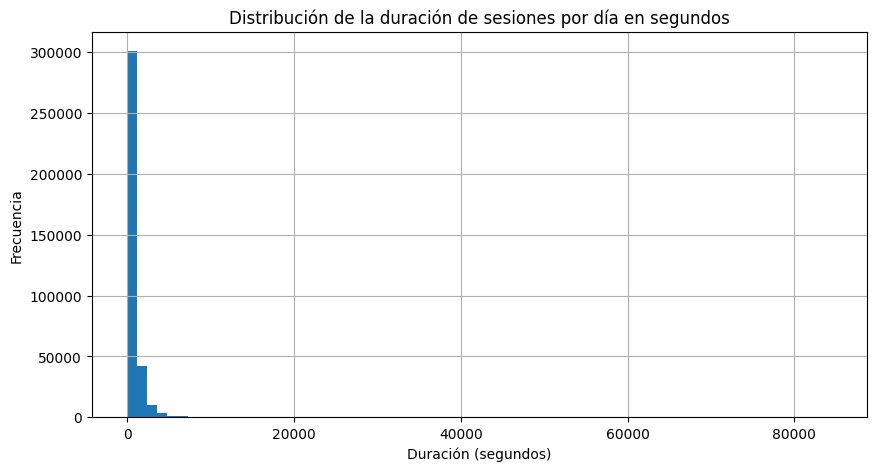

In [29]:
visits['session_duration_sec'].hist(bins=70, figsize=(10,5))
plt.title('Distribución de la duración de sesiones por día en segundos')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.show()

Como se observa en el gráfico anterior, la distribución de la duración de las sesiones no es normal, por lo que calcularemos la moda para saber qué duración tiene mayor prevalencia.

In [30]:
mode_duration= visits["session_duration_sec"].mode()
print("Moda de la duración de la sesión:")
print(mode_duration)

Moda de la duración de la sesión:
0    60
dtype: int64


+ La moda indica que la duración promedio al día con mayor prevalencia es de **60 segundos** (1 minuto). Lo anterior es factible pero no muy conveniente ya que 1 minuto generalmente no es tiempo suficiente para hacer una compra. Esto nos sugiere que los usuarios en promedio entran al sitio durante 60 segundos para revisar horarios, fechas, precios, disponibilidad pero no precisamente para continuar con el proceso de compra. 

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Excelente análisis de la duración de sesiones, combinando medidas estadísticas y su interpretación. La comparación entre promedio y moda aporta valor para entender los patrones de comportamiento de los usuarios. </div>


**4. ¿Con qué frecuencia los usuarios regresan?**

In [31]:
#Promedio de dau, wau y mau
dau_mean = dau_total["daily_users"].mean().round()
wau_mean = wau_total["weekly_users"].mean().round()
mau_mean = mau_total["monthly_users"].mean().round()

print("Promedio de usuarios diarios:", dau_mean)
print("Promedio de usuarios semanales:", wau_mean)
print("Promedio de usuarios mensuales:", mau_mean)

Promedio de usuarios diarios: 908.0
Promedio de usuarios semanales: 5716.0
Promedio de usuarios mensuales: 23228.0


In [32]:
#Calcular el sticky factor por semana y mes
sticky_wau= (dau_mean/wau_mean)*100
print("Sticky factor semanal (%):", sticky_wau.round())
print()
sticky_mau= (dau_mean/mau_mean)*100
print("Sticky factor mensual (%):", sticky_mau.round())

Sticky factor semanal (%): 16.0

Sticky factor mensual (%): 4.0


+ **Sticky factor semanal (WAU): 16%**

Significa que, en promedio, solo el 16% de los usuarios activos en una semana regresan de manera diaria. Esto indica que la mayoría de los usuarios no usan el servicio todos los días, sino que entran ocasionalmente dentro de la semana.

+ **Sticky factor mensual (MAU): 4%**

Significa que, en promedio, solo el 4% de los usuarios activos en el mes regresan de forma diaria. Esto suele ser más bajo que el semanal porque en el promedio mensual hay muchos usuarios que solo visitan el servicio una vez y no vuelven.

En conclusión:
- Existen una baja retención diaria. Esto de cierta manera es normal ya que la compra de entradas de eventos no suele ser diarimente, es más común que sea semanal o por temporadas.

Sin embargo, el sticky factor puede servir para comparar con datos históricos o evaluar si campañas de marketing aumentan la recurrencia.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Muy buen uso del sticky factor para evaluar la recurrencia. La interpretación es clara y realista respecto al tipo de servicio, lo que demuestra criterio analítico en la explicación de la baja retención diaria. </div>


#### Métricas de "Ventas"

**1.¿Cuándo empieza la gente a comprar?**

**Objetivo:**
Saber cuánto tiempo pasa desde la primera visita hasta la primera compra. Esto sirve para entender el ciclo de conversión.

In [33]:
# Obtener fecha de primera compra por usuario
first_purchase = orders.groupby("uid")["buy_ts"].min().reset_index()
first_purchase.columns = ["uid", 'first_purchase_date']
first_purchase.head(10)

,uid,first_purchase_date
0,313578113262317,2018-01-03 21:51:00
1,1575281904278712,2017-06-03 10:13:00
2,2429014661409475,2017-10-11 18:33:00
3,2464366381792757,2018-01-28 15:54:00
4,2551852515556206,2017-11-24 10:14:00
5,3077748354309989,2018-03-03 12:33:00
6,3605148382144603,2017-09-21 20:56:00
7,3753586865891862,2018-03-03 13:50:00
8,4808417689019433,2018-01-09 23:32:00
9,4992223027560440,2018-04-04 13:54:00


In [34]:
#Obtener fecha de primera visita
first_visit = visits.groupby("uid")["start_ts"].min().reset_index()
first_visit.columns = ["uid", "first_visit_date"]

# Combinar fecha de primera visita con fecha de primera compra
conversion_time = first_visit.merge(first_purchase, on="uid", how="left")

#Agregar mes de cohorte de acuerdo a su primera visita 
conversion_time["cohort_month"] = first_visit["first_visit_date"].dt.to_period('M').astype(str)

conversion_time.head(10)

,uid,first_visit_date,first_purchase_date,cohort_month
0,11863502262781,2018-03-01 17:27:00,NaT,2018-03
1,49537067089222,2018-02-06 15:55:00,NaT,2018-02
2,297729379853735,2017-06-07 18:47:00,NaT,2017-06
3,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,2017-09
4,325320750514679,2017-09-30 14:29:00,NaT,2017-09
5,397399764396656,2018-01-18 12:32:00,NaT,2018-01
6,407573351275847,2017-06-17 13:40:00,NaT,2017-06
7,498809019029702,2018-02-21 22:09:00,NaT,2018-02
8,526778907996220,2017-10-21 17:51:00,NaT,2017-10
9,577434573913691,2018-01-28 14:15:00,NaT,2018-01


In [35]:
# Calcular días transcurridos entre fechas
conversion_time["days_to_conversion"] = (
    conversion_time["first_purchase_date"] - conversion_time["first_visit_date"]
).dt.days

conversion_time.sample(10)

,uid,first_visit_date,first_purchase_date,cohort_month,days_to_conversion
3000,247851286637643790,2017-10-31 19:06:00,2017-10-31 19:13:00,2017-10,0.0
127958,10338299936598685992,2017-09-29 16:46:00,NaT,2017-09,NaN
155205,12545577378392393963,2017-12-05 03:49:00,NaT,2017-12,NaN
19389,1573046150516772485,2018-05-12 17:22:00,NaT,2018-05,NaN
216840,17520027916050724090,2017-11-21 18:52:00,NaT,2017-11,NaN
140392,11337398325035563844,2018-04-21 12:24:00,NaT,2018-04,NaN
109724,8870357881934317317,2017-10-09 16:11:00,NaT,2017-10,NaN
35946,2908059643938228321,2017-09-22 16:22:00,NaT,2017-09,NaN
116335,9406489067660288858,2018-02-07 18:14:00,NaT,2018-02,NaN
189934,15354987126309028848,2018-03-26 09:14:00,NaT,2018-03,NaN


In [36]:
print(conversion_time['days_to_conversion'].describe())
print()
print("Moda:", conversion_time['days_to_conversion'].mode())

count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: days_to_conversion, dtype: float64

Moda: 0    0.0
dtype: float64


+ En promedio el tiempo de conversión es de 17 días.
+ El tiempo mínimo de conversión es de 0 días, indicando que la compra se realizó el mismo día de la primera visita.
+ También se registró un tiempo máximo de 363 días, lo cual puede ser posible ya que existen eventos que liberan entradas hasta 1 año antes de su presentación.
+ Y al calcular la moda (0 días) nos damos cuenta que la mayoría hace la compra el mismo día que visita la página por primera vez.

In [37]:
#Crear cohortes de acuerdo al tiempo de conversión
conversion_time['conversion_category'] = np.where(
    conversion_time['first_purchase_date'].isna(), 'No conversion',
    np.where(conversion_time['days_to_conversion'] == 0, '0d',
    np.where(conversion_time['days_to_conversion'] == 1, '1d',
    np.where(conversion_time['days_to_conversion'] <= 7, '2-7d',
    np.where(conversion_time['days_to_conversion'] <= 14, '8-14d',
    np.where(conversion_time['days_to_conversion'] <= 30, '15-30d', '30d+')
)))))

conversion_time.sample(5)

,uid,first_visit_date,first_purchase_date,cohort_month,days_to_conversion,conversion_category
36368,2940780697267113605,2018-01-20 17:15:00,NaT,2018-01,NaN,No conversion
51650,4172873654472617732,2018-03-17 15:09:00,NaT,2018-03,NaN,No conversion
117503,9504360392856622632,2017-09-18 18:33:00,NaT,2017-09,NaN,No conversion
55564,4490872362326773636,2018-02-27 12:30:00,NaT,2018-02,NaN,No conversion
9479,775837719870642829,2017-12-02 21:09:00,2018-03-05 21:01:00,2017-12,92.0,30d+


In [38]:
#Crear tabla pivote para obtener el total de usuarios por categoría
conversion_pivot = (conversion_time.pivot_table(index="conversion_category", 
                                                values="uid", 
                                                aggfunc="count")
    .rename(columns={"uid": "n_users"}))

#Agregar columna con % de conversión por categoría
conversion_pivot['% conversion'] = ((conversion_pivot['n_users'] / conversion_pivot['n_users'].sum()) 
                                    * 100).round(2)

conversion_pivot.sort_values(by= "n_users", ascending= False)

,n_users,% conversion
conversion_category,,
No conversion,191646,83.99
0d,26363,11.55
30d+,4902,2.15
2-7d,2069,0.91
15-30d,1250,0.55
1d,1011,0.44
8-14d,928,0.41


+ De acuerdo a la tabla anterior se puede concluir que existen 191,646 usuarios que visitaron la página por primera vez pero no realizaron ninguna compra, por lo cual fueron etiquetados como "No conversion". Estos usuarios representan la mayoría con un 84%.
+ Se registraron 26,363 usuarios (11.55%) que visitaron la página por primera vez y realizaron una compra el mismo día, conversión de "0d".
+ En tercer lugar se situaron los usuarios que realizaron compras después de 1 mes de la primera visita, con un total de 4,902 compradores (2.15%)
+ Los usuarios que realizaron una compra entre los días 2-7 posteriores a su primer visita, alcanzaron un total de 2,069 (0.91%).
+ Aquellos usuarios que realizaron una compra 1 día después de su primer visita representan el 0.44% con un toal de 1,011 compras.
+ Finalmente, el menor porcentaje (0.41%) corresponde a los que hacen compras en la segunda semana después de la primera visita.

En conclusión, el 84% de los usuarios han visitado el sitio pero no completaron alguna compra. El 11.5% de los usuarios normalmente completan la compra el mismo día en el que realizan su primera visita al sitio y en algunos casos, el 2% de los usuarios esperan más de un mes para completarla.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Gran trabajo en el análisis del tiempo de conversión y la segmentación por categorías. La interpretación de los resultados es clara y ayuda a comprender el comportamiento de compra de los usuarios de manera precisa. </div>


**Análisis de cohortes mensuales**

A continuación se agruparán a los usuarios por el mes en que se registraron y la categoría de conversión para posteriormente determinar el porcentaje de conversión de cada cohorte.

In [39]:
monthly_conversion= conversion_time.pivot_table(columns= "conversion_category",
                                               index= "cohort_month",
                                               values= "uid",
                                               aggfunc="count")

monthly_conversion_pct= (monthly_conversion.div(monthly_conversion.sum(axis=1), axis=0)*100).round(1)
monthly_conversion_pct

conversion_category,0d,15-30d,1d,2-7d,30d+,8-14d,No conversion
cohort_month,,,,,,,
2017-06,13.6,0.7,0.4,0.9,6.0,0.4,78.0
2017-07,11.6,0.4,0.4,0.9,5.0,0.4,81.3
2017-08,10.8,0.6,0.3,0.7,4.2,0.3,83.1
2017-09,11.8,0.9,0.4,1.1,3.6,0.5,81.7
2017-10,12.7,0.7,0.5,1.0,2.7,0.4,82.0
2017-11,10.5,0.7,0.5,1.0,2.3,0.6,84.4
2017-12,11.8,0.5,0.5,1.0,1.8,0.4,83.9
2018-01,10.3,0.6,0.4,0.9,1.3,0.4,86.2
2018-02,11.2,0.5,0.4,1.0,0.8,0.4,85.6


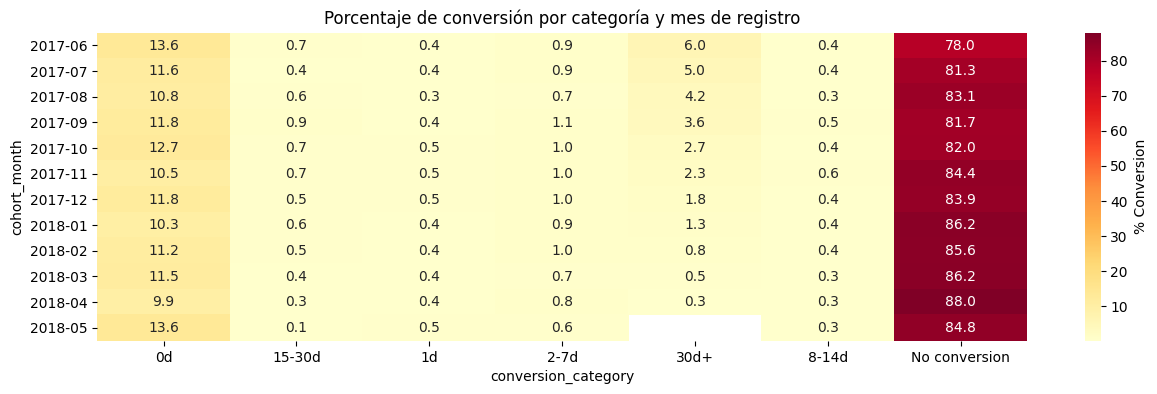

In [40]:
#Mapa de calor 
plt.figure(figsize=(15,4))
plt.title('Porcentaje de conversión por categoría y mes de registro')
sns.heatmap(
    monthly_conversion_pct,
    annot=True,
    fmt='.1f',
    cmap= 'YlOrRd',
    cbar_kws={'label': '% Conversion'})

plt.yticks(rotation=0)
plt.show()

+ De acuerdo a la gráfica anterior, se puede concluir que las cohortes correspondiente al mes de Junio 2017 y Mayo 2018 tuvieron mayor tasa de conversión (13.6%) en la categoría "0d" que corresponde al mismo día en que se realizó la primera visita.
+ En general, confirmamos que a lo largo del año, los usuarios tienden a realizar la compra el mismo día en que visitan el sitio por primera vez, aunque también se oberva una tendencia en períodos posteriores a 30 días (30d+), especialmente en el período comprendido entre Junio 2017 a Septiembre 2017.
+ La tasa de "No conversion" incrementó durante el año, pasando de 78% en Junio 2017 hasta 88% en Abril de 2018, lo cual indica que las personas dejaron de completar la compra conforme pasaban los meses.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Muy buen desarrollo del análisis de cohortes mensuales. El uso del mapa de calor y la interpretación de tendencias aporta gran claridad sobre cómo evoluciona la conversión y fortalece el valor del estudio. </div>


**2. ¿Cuántos pedidos hacen durante un período de tiempo dado?**

**Objetivo:**
Medir la frecuencia de compra de los clientes en un tiempo específico.

In [41]:
#Extraer componentes de fecha de buy_ts
orders['buy_date'] = orders['buy_ts'].dt.date
orders['buy_day'] = orders['buy_ts'].dt.day
orders['buy_month'] = orders['buy_ts'].dt.month
orders['buy_year'] = orders['buy_ts'].dt.year
orders['buy_month_year'] = orders['buy_ts'].dt.to_period('M')

orders.head()

,buy_ts,revenue,uid,buy_date,buy_day,buy_month,buy_year,buy_month_year
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,1,6,2017,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,1,6,2017,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,1,6,2017,2017-06
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,1,6,2017,2017-06
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,1,6,2017,2017-06


In [42]:
#Crear cohortes de usuarios para identificar a cuál pertenece cada usuario según su primera compra
user_cohorts = orders.groupby("uid")["buy_month_year"].min().reset_index()
user_cohorts.columns=["uid", "cohort_month"]
user_cohorts.head()

,uid,cohort_month
0,313578113262317,2018-01
1,1575281904278712,2017-06
2,2429014661409475,2017-10
3,2464366381792757,2018-01
4,2551852515556206,2017-11


In [43]:
#Unir a dataset "orders"
orders_cohorts = orders.merge(user_cohorts, on="uid", how="left")
orders_cohorts.head()

,buy_ts,revenue,uid,buy_date,buy_day,buy_month,buy_year,buy_month_year,cohort_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,1,6,2017,2017-06,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,1,6,2017,2017-06,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,1,6,2017,2017-06,2017-06
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,1,6,2017,2017-06,2017-06
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,1,6,2017,2017-06,2017-06


In [44]:
#Calcular total de pedidos por mes y cohorte
total_cohort_orders= orders_cohorts.groupby(['cohort_month', 'buy_month_year']).agg({
    'uid': 'count',  # Total de pedidos
    'revenue': 'sum'  # Revenue total
}).reset_index()

total_cohort_orders.columns = ['cohort_month', 'purchase_month', 'total_orders', 'total_revenue']
total_cohort_orders.head(10)

,cohort_month,purchase_month,total_orders,total_revenue
0,2017-06,2017-06,2354,9557.49
1,2017-06,2017-07,177,981.82
2,2017-06,2017-08,174,885.34
3,2017-06,2017-09,226,1931.30
4,2017-06,2017-10,292,2068.58
5,2017-06,2017-11,218,1487.92
6,2017-06,2017-12,276,1922.74
7,2017-06,2018-01,174,1176.56
8,2017-06,2018-02,212,1119.15
9,2017-06,2018-03,153,1225.51


In [45]:
#Crear tabla pivote para total de órdenes
pivot_orders = total_cohort_orders.pivot(
    index='cohort_month', 
    columns='purchase_month', 
    values='total_orders'
).fillna(0)

pivot_orders

purchase_month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06
cohort_month,,,,,,,,,,,,,
2017-06,2354.0,177.0,174.0,226.0,292.0,218.0,276.0,174.0,212.0,153.0,96.0,86.0,0.0
2017-07,0.0,2186.0,100.0,120.0,104.0,72.0,82.0,61.0,50.0,58.0,24.0,53.0,0.0
2017-08,0.0,0.0,1533.0,108.0,100.0,81.0,85.0,62.0,49.0,78.0,46.0,46.0,0.0
2017-09,0.0,0.0,0.0,2933.0,219.0,161.0,164.0,67.0,109.0,108.0,56.0,61.0,0.0
2017-10,0.0,0.0,0.0,0.0,4964.0,314.0,162.0,122.0,129.0,103.0,86.0,125.0,0.0
2017-11,0.0,0.0,0.0,0.0,0.0,4813.0,397.0,182.0,211.0,136.0,59.0,102.0,0.0
2017-12,0.0,0.0,0.0,0.0,0.0,0.0,5052.0,270.0,202.0,179.0,86.0,105.0,0.0
2018-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3783.0,224.0,159.0,64.0,78.0,0.0
2018-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4095.0,222.0,83.0,70.0,0.0


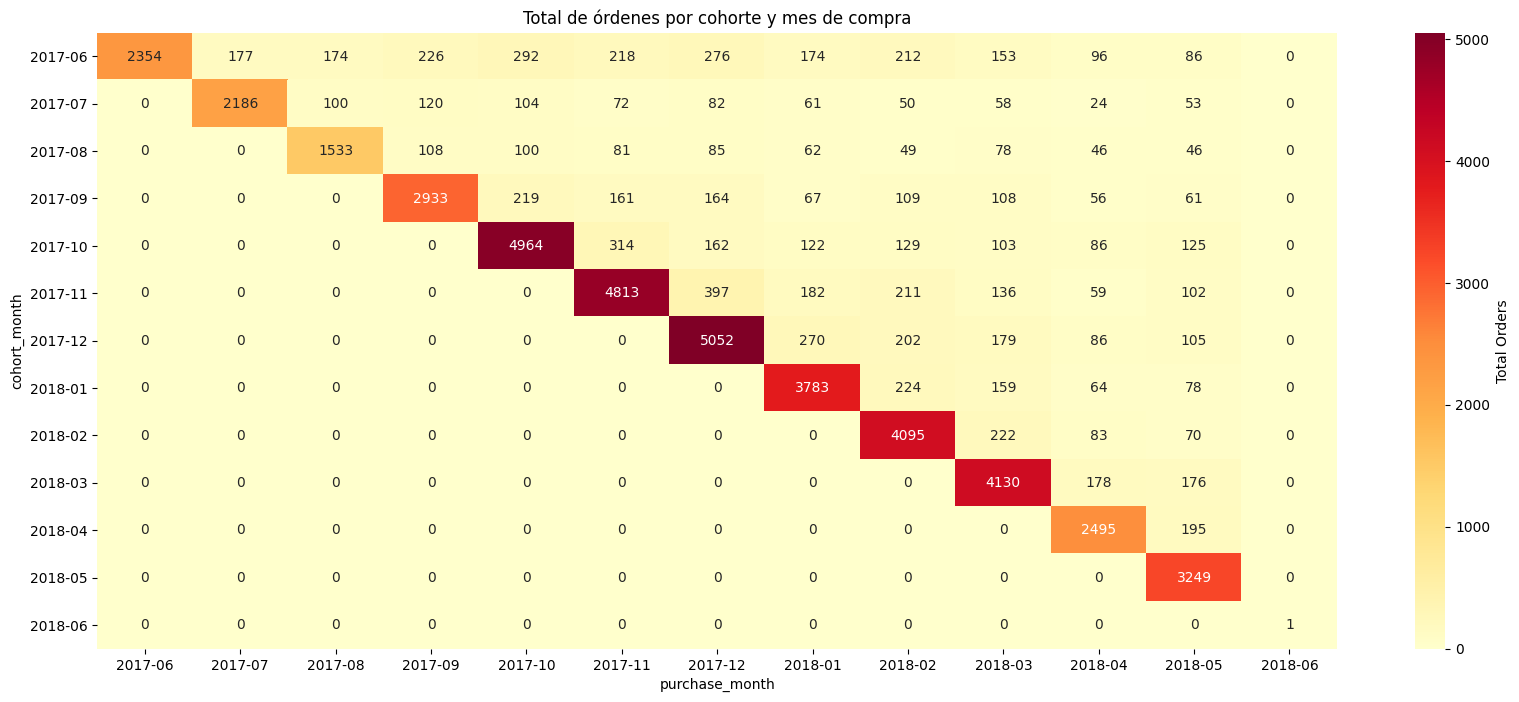

In [46]:
#Visualizar con un heatmap

plt.figure(figsize=(20, 8))
plt.title('Total de órdenes por cohorte y mes de compra')

sns.heatmap(pivot_orders, 
            annot=True, 
            fmt='.0f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Total Orders'})

plt.yticks(rotation=0)
plt.show()

+ El gráfico anterior nos ayuda a entender el comportamiendo de compra de los usuarios a lo largo del tiempo. 
+ La diagonal muestra los valores correspondientes al total de compras de cada cohorte por primera vez, y es natural que representen los valores más altos. Por ejemplo, en Junio de 2017 se registraron 2,354 compras en total, sin embargo el mes siguiente correspondiente a Julio 2017 disminuyó a 177 compras.
+ Generalmente en el primer mes de compra de cada cohorte se obtuvieron mayores números de órdenes en comparación a meses posteriores. Esta disminución ayuda a observar el comportamiento real de retención conforme avanza el tiempo.
+ Durante el año analizado, se observó que la cohorte correspondiente a Diciembre 2017 resgitró un total de 5,052 órdenes por primera mes, mientras que la cohorte de Agosto de 2017 registró apenas 1,533 órdenes.
+ La cohorte de Junio 2017 (la más antigua), reportó valores estables a lo largo del tiempo, lo que nos indica que los usuarios regresaron a hacer compras cada mes, especialmente en el periodo de Septiembre 2017 a Febrero 2018.
+ Otras cohortes fuertes fueron las de Octubre, Noviembre y Diciembre de 2017, ya que las órdenes iniciales fueron altas y se mantuvieron en los meses posteriores.
+ Finalmente, en general se puede observar que las cohortes de Octubre 2017 a Marzo 2018 son las que presentaron mayores compras durante su primer mes, y que los clientes regresan mensualmente y se mantienen las compras estables hasta el mes de Marzo 2018.

In [47]:
#Crear tabla pivote para revenue total
pivot_revenue = total_cohort_orders.pivot(
    index='cohort_month', 
    columns='purchase_month', 
    values='total_revenue'
).fillna(0)

display(pivot_revenue)

purchase_month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06
cohort_month,,,,,,,,,,,,,
2017-06,9557.49,981.82,885.34,1931.30,2068.58,1487.92,1922.74,1176.56,1119.15,1225.51,1155.66,519.62,0.00
2017-07,0.00,11557.65,644.61,1199.05,690.31,339.97,300.08,231.16,272.72,310.05,282.96,299.36,0.00
2017-08,0.00,0.00,7228.83,646.63,628.12,536.05,676.85,388.45,288.61,554.86,400.33,257.53,0.00
2017-09,0.00,0.00,0.00,14568.53,2884.49,1344.52,10261.52,1033.84,1670.08,1810.85,627.57,474.92,0.00
2017-10,0.00,0.00,0.00,0.00,21716.20,2325.21,830.65,682.01,657.77,522.37,368.10,501.14,0.00
2017-11,0.00,0.00,0.00,0.00,0.00,21036.26,1629.27,814.39,1326.13,604.04,219.88,469.02,0.00
2017-12,0.00,0.00,0.00,0.00,0.00,0.00,20767.49,1141.22,4054.70,4669.10,1371.57,1481.66,0.00
2018-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,13949.50,994.22,1026.34,481.59,211.48,0.00
2018-02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,15177.16,1015.98,286.66,270.70,0.00


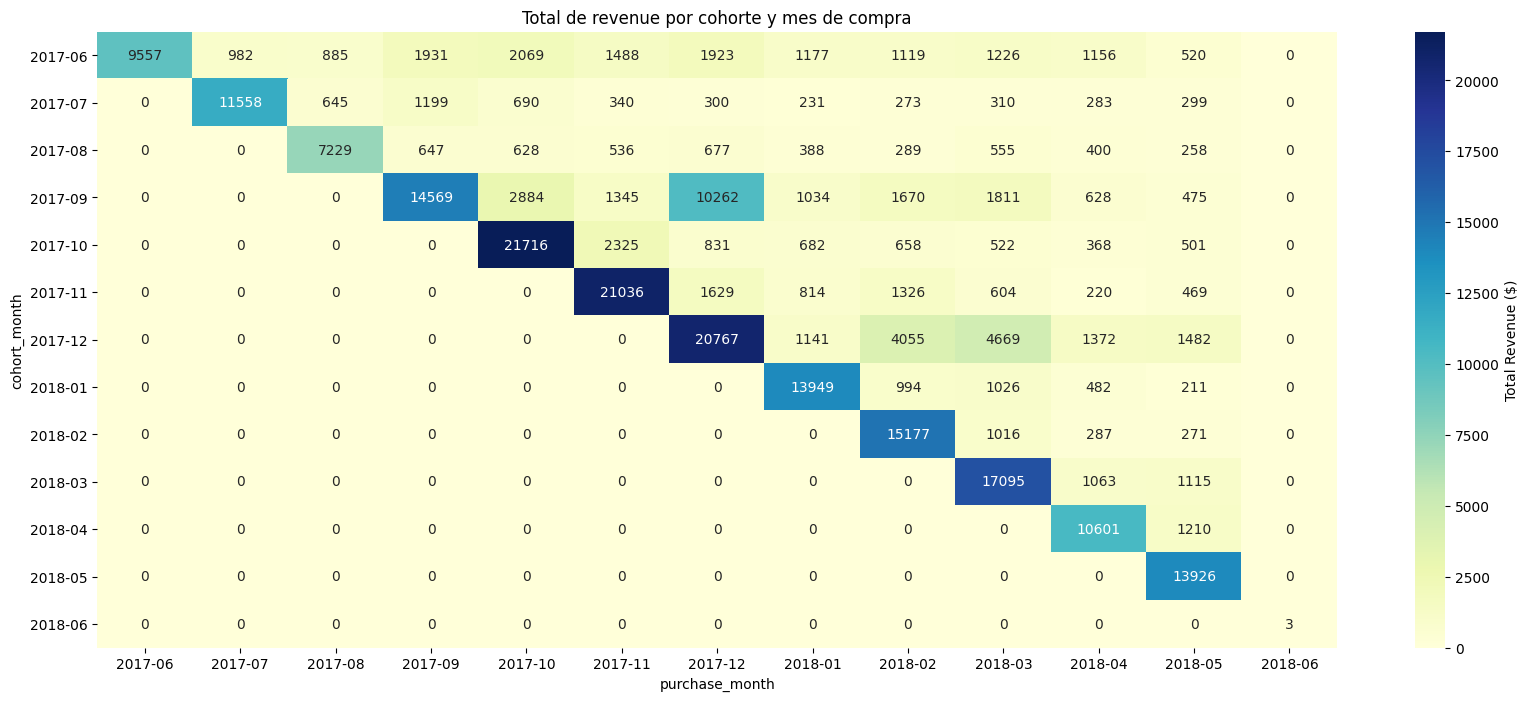

In [48]:
#Visualizar con un heatmap
plt.figure(figsize=(20, 8))
plt.title('Total de revenue por cohorte y mes de compra')

sns.heatmap(pivot_revenue, 
            annot=True, 
            fmt='.0f',
            cmap='YlGnBu',
            cbar_kws={'label': 'Total Revenue ($)'})

plt.yticks(rotation=0)
plt.show()

+ El gráfico anterior nos ayuda a entender no sólo cuántas compras hacen los usuarios, sino también cuánto gastan en total.
+ Generalmente las cohortes con mayor número de órdenes iniciales (el caso de Octubre, Noviembre y Diciembre de 2017) son las que reportaron mayor revenue. Sin embargo, hay una ligera diferencia en la relación órdenes-revenue de esos meses. Por ejemplo en Diciembre se reportó un total de 5,052 órdenes en el primer mes con un revenue de 20,767; sin embargo el revenue en Octubre 2017 fue mayor con un total de 21,716 proveniente de 4,964 órdenes iniciales. Esto nos ayuda a constatar que no siempre las cohortes con mayores ventas iniciales son las que generan mayor revenue.
+ En el caso de la cohorte Septiembre 2017, se observó un aumento desproporcionalmente alto en el revenue correspondiente al mes de Diciembre 2017 con un total de 10,262 que provenía sólo de 164 compras. Esto podría deberse a la compra de productos con un valor más alto derivado de eventos más exclusivos o que no ocurren con mucha frecuencia.
+ En el caso de la primera cohorte (Junio 2017), se observan valores estables en el revenue a lo largo del tiempo, como ya se había encontrado anteriormente en el número de órdenes totales.
+ En general se puede observar que las cohortes con mayor revenue a lo largo del tiempo fueron las de Septiembre 2017 a Diciembre 2017.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Excelente construcción de cohortes y análisis tanto de órdenes como de revenue. Las visualizaciones y conclusiones están bien fundamentadas y muestran una clara comprensión del comportamiento de compra y gasto de los usuarios. </div>


**3. ¿Cuál es el tamaño promedio de compra?**

In [49]:
# Calcular el tamaño promedio de compra por cohorte y período
avg_purchase= pivot_revenue/pivot_orders
avg_purchase.round(2).fillna(0)

purchase_month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06
cohort_month,,,,,,,,,,,,,
2017-06,4.06,5.55,5.09,8.55,7.08,6.83,6.97,6.76,5.28,8.01,12.04,6.04,0.00
2017-07,0.00,5.29,6.45,9.99,6.64,4.72,3.66,3.79,5.45,5.35,11.79,5.65,0.00
2017-08,0.00,0.00,4.72,5.99,6.28,6.62,7.96,6.27,5.89,7.11,8.70,5.60,0.00
2017-09,0.00,0.00,0.00,4.97,13.17,8.35,62.57,15.43,15.32,16.77,11.21,7.79,0.00
2017-10,0.00,0.00,0.00,0.00,4.37,7.41,5.13,5.59,5.10,5.07,4.28,4.01,0.00
2017-11,0.00,0.00,0.00,0.00,0.00,4.37,4.10,4.47,6.28,4.44,3.73,4.60,0.00
2017-12,0.00,0.00,0.00,0.00,0.00,0.00,4.11,4.23,20.07,26.08,15.95,14.11,0.00
2018-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.69,4.44,6.45,7.52,2.71,0.00
2018-02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.71,4.58,3.45,3.87,0.00


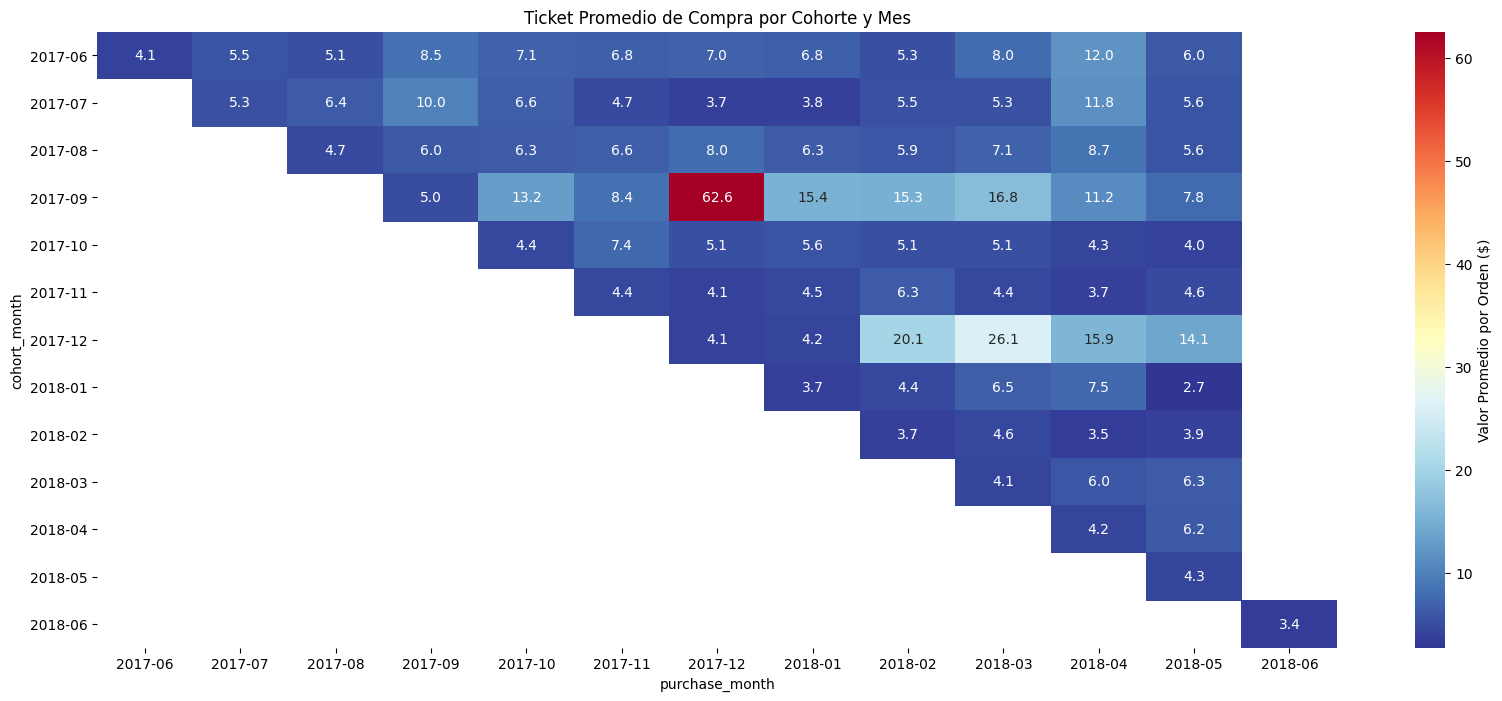

In [50]:
#Crear heatmap
plt.figure(figsize=(20, 8))
plt.title('Ticket Promedio de Compra por Cohorte y Mes')

sns.heatmap(avg_purchase, 
            annot=True, 
            fmt='.1f',
            cmap='RdYlBu_r',
            cbar_kws={'label': 'Valor Promedio por Orden ($)'})

plt.yticks(rotation=0)
plt.show()


* De acuerdo al gráfico anterior, se observa claramente que la cohorte de Septiembre 2017 fue la que generó más revenue durante el mes de Diciembre 2017, con un promedio de 62.6 , y en general esa cohorte se mantuvo constante en revenue medianamente altos a lo largo de los siguientes meses.
* Otra cohorte que también destacó fue la de Diciembre 2017, generando revenues medianamente altos durante los meses de Febrero y Marzo 2018 con un promedio mayor a 20.
* También se observa que algunas cohortes generaron un revenue mayor durante el mes de Abril 2018, comparado a sus revenues de meses anteriores.
* Finalmente, si comparamos este gráfico con el de los valores totales de revenue por cohorte, podemos observar que en ambos los valores correspondientes a la cohorte de Septiembre 2017 en el mes de Diciembre 2017, coinciden en ser altos. De igual forma para la cohorte de Diciembre 2017, coinciden los valores promedio de compra medianamente altos con los del revenue total durante los meses de Febrero y Marzo 2018.
* Sin embargo, no hay coinciencia en las primeras compras de las cohortes Octubre, Noviembre y Diciembre 2017 que fueron las que presentaron mayor revenue total, ya que el promedio de compra apenas es de más de 4($).
* En conclusión, las cohortes de Octubre, Noviembre y Diciembre 2017 tienen alto volumen pero bajo valor promedio, mientras que Septiembre tiene bajo volumen pero alto valor.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Muy bien logrado el análisis del ticket promedio, con un enfoque comparativo que resalta diferencias entre volumen y valor de compra por cohorte. La conclusión está bien fundamentada y aporta una visión estratégica clara. </div>


**4. ¿Cuánto dinero traen? (LTV)** 

**Objetivo:** Estimar cuánto dinero genera una cohorte a lo largo del período de tiempo analizado.

In [51]:
# Calcular el LTV acumulativo por cohorte
ltv_table = pivot_revenue.cumsum(axis=1)

ltv_table.round(2)

purchase_month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06
cohort_month,,,,,,,,,,,,,
2017-06,9557.49,10539.31,11424.65,13355.95,15424.53,16912.45,18835.19,20011.75,21130.90,22356.41,23512.07,24031.69,24031.69
2017-07,0.00,11557.65,12202.26,13401.31,14091.62,14431.59,14731.67,14962.83,15235.55,15545.60,15828.56,16127.92,16127.92
2017-08,0.00,0.00,7228.83,7875.46,8503.58,9039.63,9716.48,10104.93,10393.54,10948.40,11348.73,11606.26,11606.26
2017-09,0.00,0.00,0.00,14568.53,17453.02,18797.54,29059.06,30092.90,31762.98,33573.83,34201.40,34676.32,34676.32
2017-10,0.00,0.00,0.00,0.00,21716.20,24041.41,24872.06,25554.07,26211.84,26734.21,27102.31,27603.45,27603.45
2017-11,0.00,0.00,0.00,0.00,0.00,21036.26,22665.53,23479.92,24806.05,25410.09,25629.97,26098.99,26098.99
2017-12,0.00,0.00,0.00,0.00,0.00,0.00,20767.49,21908.71,25963.41,30632.51,32004.08,33485.74,33485.74
2018-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,13949.50,14943.72,15970.06,16451.65,16663.13,16663.13
2018-02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,15177.16,16193.14,16479.80,16750.50,16750.50


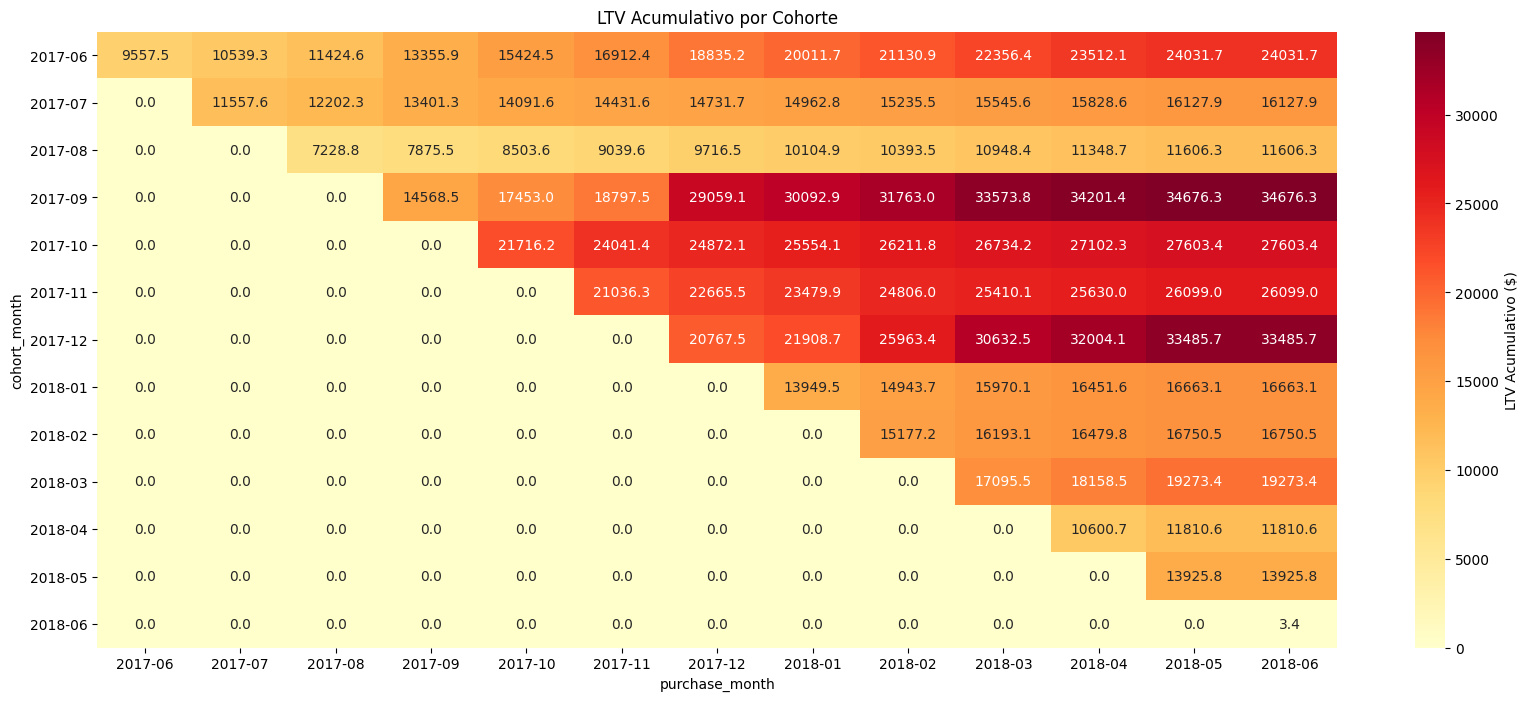

In [52]:
#Crear un heatmap
plt.figure(figsize=(20, 8))
plt.title('LTV Acumulativo por Cohorte')

sns.heatmap(ltv_table, 
            annot=True, 
            fmt='.1f',
            cmap='YlOrRd',
            cbar_kws={'label': 'LTV Acumulativo ($)'})

plt.yticks(rotation=0)
plt.show()


+ La cohorte que tuvo el LTV más alto fue la Septiembre 2017 durante el mes de Mayo 2018 con un valor de 34,676.3, seguida de la cohorte Diciembre 2017 con un valor de 33,485.7
+ Otras cohortes con LTV altos fueron las de Octubre y Noviembre 2017 con valores mayores a 26,000.
+ En general, en todas las cohortes el LTV va en aumento conforme avanzan los meses.
+ La cohorte que tuvo menor LTV fue la de Agosto 2017 con un valor de 11,606.3 ($) acumulados a lo largo de 10 meses.
+ Se observa una tendencia a alcanzar LTV altos durante el periodo de Diciembre 2017 a Mayo 2018.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Muy buen cálculo del LTV acumulativo y su análisis comparativo entre cohortes. La interpretación es clara y destaca correctamente las cohortes con mayor y menor valor, mostrando un entendimiento sólido de la métrica. </div>


**LTV promedio por usuario**

In [53]:
#Calcular número de usuarios por cohorte
users_per_cohort= orders_cohorts.groupby("cohort_month")["uid"].nunique().reset_index()
users_per_cohort.columns= ("cohort_month", "n_users")
users_per_cohort

,cohort_month,n_users
0,2017-06,2023
1,2017-07,1923
2,2017-08,1370
3,2017-09,2581
4,2017-10,4340
5,2017-11,4081
6,2017-12,4383
7,2018-01,3373
8,2018-02,3651
9,2018-03,3533


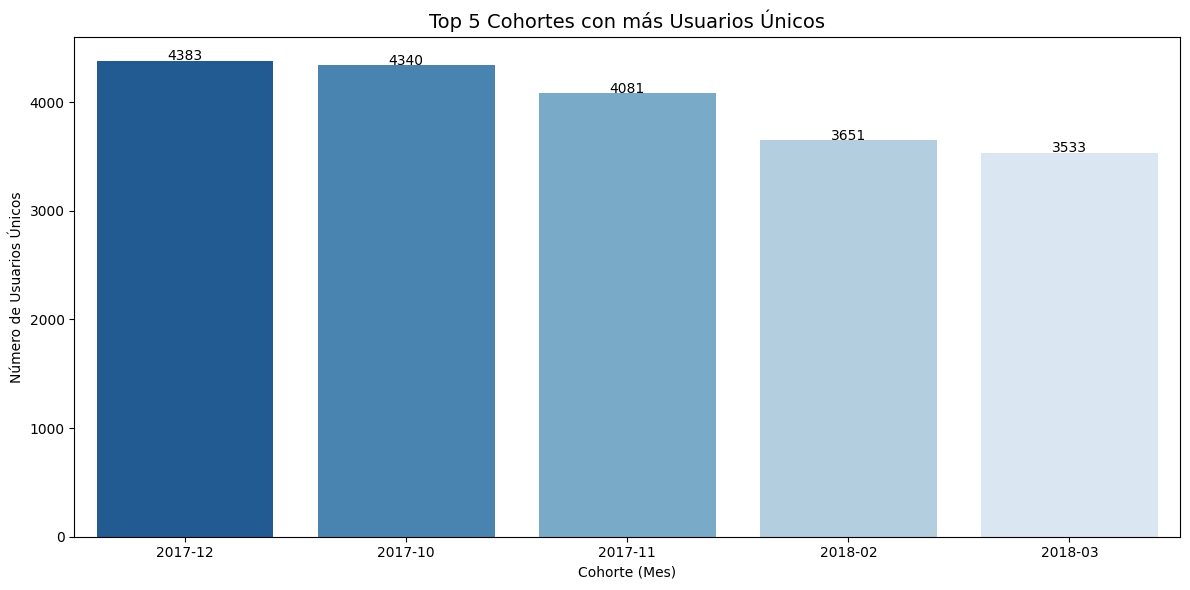

In [54]:
#top 5 de cohortes por número de usuarios
top5 = users_per_cohort.sort_values("n_users", ascending=False).head(5)

plt.figure(figsize=(12,6))
ax= sns.barplot(
    data=top5,
    x="cohort_month",
    y="n_users",
    palette="Blues_r"
)

for i, value in enumerate(top5["n_users"]):
    ax.text(i, value + 5, str(value), ha="center")

plt.title("Top 5 Cohortes con más Usuarios Únicos", fontsize=14)
plt.ylabel("Número de Usuarios Únicos")
plt.xlabel("Cohorte (Mes)")
plt.tight_layout()
plt.show()

In [55]:
#Dividir el revenue acumulado entre el número de usuarios
ltv_avg = ltv_table.div(users_per_cohort.set_index("cohort_month")["n_users"], axis=0)
ltv_avg = ltv_avg.round(2)
ltv_avg

purchase_month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06
cohort_month,,,,,,,,,,,,,
2017-06,4.72,5.21,5.65,6.60,7.62,8.36,9.31,9.89,10.45,11.05,11.62,11.88,11.88
2017-07,0.00,6.01,6.35,6.97,7.33,7.50,7.66,7.78,7.92,8.08,8.23,8.39,8.39
2017-08,0.00,0.00,5.28,5.75,6.21,6.60,7.09,7.38,7.59,7.99,8.28,8.47,8.47
2017-09,0.00,0.00,0.00,5.64,6.76,7.28,11.26,11.66,12.31,13.01,13.25,13.44,13.44
2017-10,0.00,0.00,0.00,0.00,5.00,5.54,5.73,5.89,6.04,6.16,6.24,6.36,6.36
2017-11,0.00,0.00,0.00,0.00,0.00,5.15,5.55,5.75,6.08,6.23,6.28,6.40,6.40
2017-12,0.00,0.00,0.00,0.00,0.00,0.00,4.74,5.00,5.92,6.99,7.30,7.64,7.64
2018-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.14,4.43,4.73,4.88,4.94,4.94
2018-02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.16,4.44,4.51,4.59,4.59


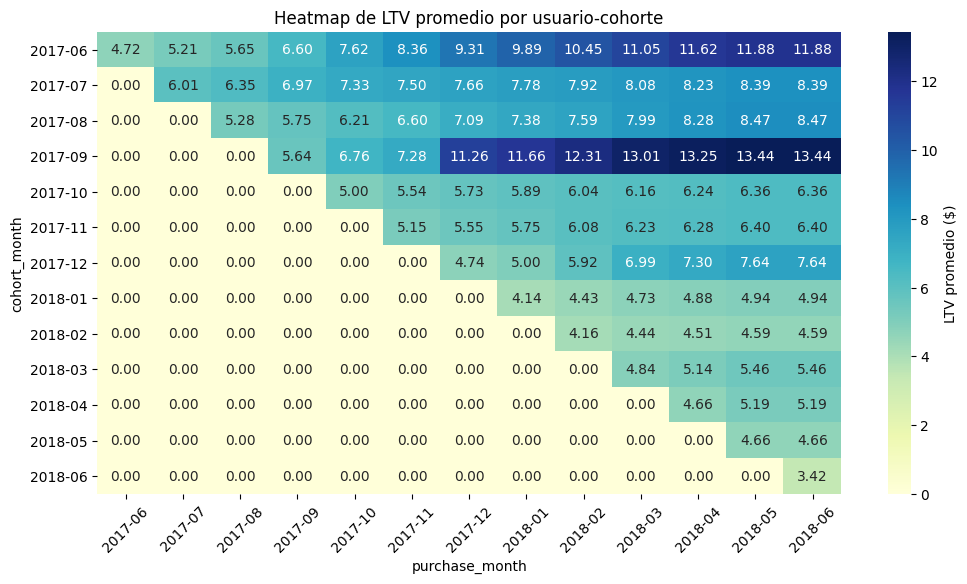

In [56]:
#Heatmap LTV por usuario
plt.figure(figsize=(12, 6))

sns.heatmap(ltv_avg,                
    annot=True,             
    fmt=".2f",             
    cmap="YlGnBu",
    cbar_kws={'label': 'LTV promedio ($)'}
)

plt.title("Heatmap de LTV promedio por usuario-cohorte")
plt.xticks(rotation= 45)
plt.show()

+ El heatmap muestra el valor promedio generado por cada usuario en cada cohorte a lo largo del tiempo desde su primer mes de compra.

+ La cohorte que tuvo mayor LTV promedio por usuario al inicio fue la de Julio 2017 y se mantuvo estable conforme avanzaron los meses. El LTV total alcanzado fue de 8.39. Este aumento gradual y sostenido sugiere buena retención y compras repetidas de los usuarios.

+ Las cohortes que tuvieron mejor desempeño corresponden a la de Junio 2017 y Septiembre 2017, especialmente durante los meses de Diciembre 2017 a Mayo 2018. La cohorte de Junio alcanzó un LTV total promedio de 11.88, mientras que la de Septiembre alcanzó un total promedio de 13.44.

+ También destaca la cohorte de Diciembre que alcanzó un LTV total promedio de 7.64 en un período de 6 meses. 

+ Las cohortes que se estancaron con el tiempo fueron las de Octubre y Noviembre 2017, ya que su LTV total alcanzó en promedio los 6.36 y 6.40 correspondientes.

* Cohortes más recientes como las de Mayo, Junio 2018 aún están en crecimiento por lo que su LTV es bajo. Esto es normal debido a que tienen menos meses de datos acumulados.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Excelente cálculo e interpretación del LTV promedio por usuario. El análisis comparativo entre cohortes está bien explicado y refleja una comprensión sólida sobre retención y valor generado en el tiempo. </div>


**Análsis de ventas por dispositivo**

In [57]:
# Combinar orders con visits para extraer "device"
orders_with_device = orders.merge(visits[["uid","device"]], on="uid", how="left")
orders_with_device.sample(5)

,buy_ts,revenue,uid,buy_date,buy_day,buy_month,buy_year,buy_month_year,device
472833,2018-01-31 15:01:00,24.44,12780042542370479493,2018-01-31,31,1,2018,2018-01,desktop
319648,2017-12-05 14:42:00,0.61,3749803340031383941,2017-12-05,5,12,2017,2017-12,desktop
226127,2017-10-28 13:42:00,1.10,3263486045884611639,2017-10-28,28,10,2017,2017-10,desktop
9642,2017-06-09 00:14:00,2.44,3218564135470853669,2017-06-09,9,6,2017,2017-06,desktop
244671,2017-11-08 10:39:00,3.67,15137372780167445785,2017-11-08,8,11,2017,2017-11,desktop


**Revenue Total por dispositivo**

In [58]:
#Agrupar por dispositivo y calcular revenue total 
revenue_by_device= orders_with_device.groupby("device")["revenue"].sum().reset_index()
revenue_by_device.columns= ("device", "total_revenue")
revenue_by_device

,device,total_revenue
0,desktop,6.447894e+06
1,touch,5.143134e+05


**Usuarios únicos por dispositivo**

In [59]:
users_per_device= orders_with_device.groupby("device")["uid"].nunique().reset_index()
users_per_device.columns= ("device", "n_users")
users_per_device

,device,n_users
0,desktop,30602
1,touch,8912


**Ticket promedio por device**

In [60]:
ticket_avg_device = orders_with_device.groupby("device")["revenue"].mean().reset_index()
ticket_avg_device.columns = ["device", "avg_ticket"]
ticket_avg_device

,device,avg_ticket
0,desktop,9.040895
1,touch,10.579314


**Análisis de ventas por dispositivo al mes**

In [61]:

orders_device_pivot= orders_with_device.pivot_table(index= "buy_month_year",
                             columns= "device",
                             values= "uid",
                             aggfunc= "count").fillna(0)

orders_device_pivot


device,desktop,touch
buy_month_year,,
2017-06,24330.0,1509.0
2017-07,32432.0,1937.0
2017-08,34575.0,1271.0
2017-09,62715.0,2441.0
2017-10,67711.0,5912.0
2017-11,61178.0,6946.0
2017-12,95830.0,5484.0
2018-01,65799.0,3915.0
2018-02,87014.0,4288.0


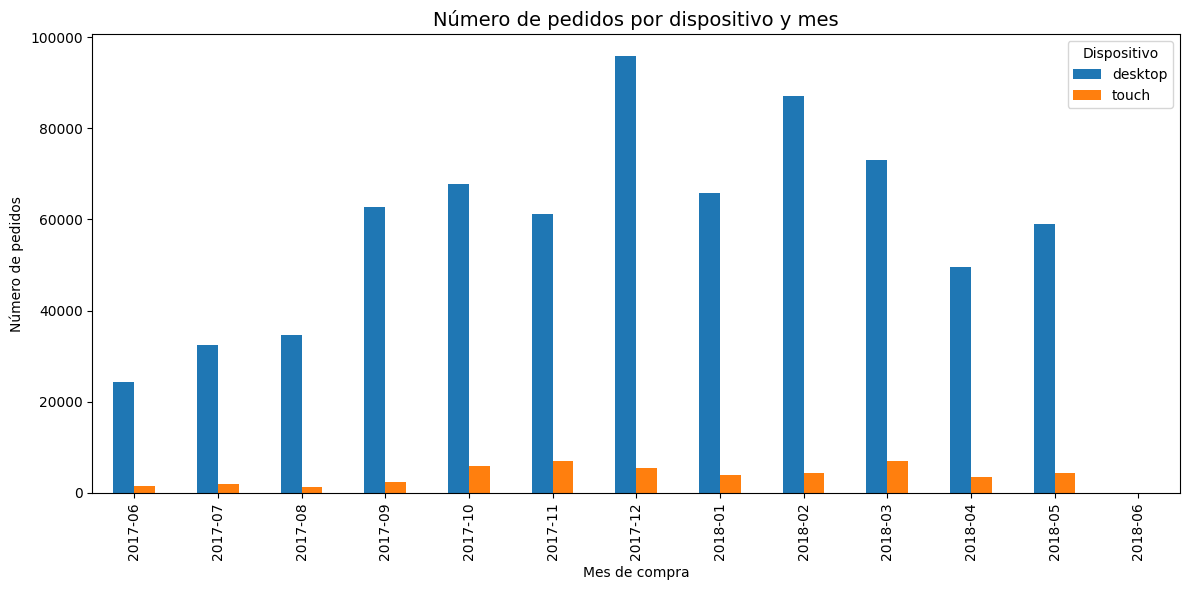

In [62]:
#Gráfica de barras
orders_device_pivot.plot(kind="bar",stacked=False,figsize=(12,6))

plt.title("Número de pedidos por dispositivo y mes", fontsize=14)
plt.xlabel("Mes de compra")
plt.ylabel("Número de pedidos")
plt.legend(title="Dispositivo")
plt.tight_layout()
plt.show()

De acuerdo a los datos analizados por dispositivo se puede concluir que:

+ El revenue generado a través de dispositivos "desktop" es mayor en comparación con los "touch", lo cual también coincide con el número de usuarios: 30,602 en "desktop" vs 8,912 en "touch". Lo anterior sugiere que hay mayor preferencia para realizar compras a través de sus computadoras que a través de sus celulares.
  
+ Sin embargo, al calcular el promedio de compra de cada dispositivo, se observa que curiosamente el ticket promedio es mayor en "touch" (10.57) vs "desktop" (9.04)

+ Los meses con mayor número de órdenes a través de dispositivos "desktop" fueron Diciembre 2017, Febrero y Marzo 2018. Mientras que para los dispositivos "touch" fueron Marzo 2018, Noviembre y Octubre 2017.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Muy buen análisis comparativo de ventas por dispositivo. Destacaste correctamente las diferencias en revenue, usuarios y ticket promedio, complementando con una lectura clara de los meses más representativos. </div>


#### Métricas de "Marketing"

**1. ¿Cuánto dinero se gastó?**

**Gasto Total:**

In [63]:
gasto_total = costs["costs"].sum()
print("El Gasto Total de la empresa Showz en el período Junio 2017 - Mayo 2018 fue: $",gasto_total)

El Gasto Total de la empresa Showz en el período Junio 2017 - Mayo 2018 fue: $ 329131.62


**Gasto total por fuente de adquisición:**

In [64]:
#Agrupar por fuente de adquisición y obtener gasto 
cost_source= costs.groupby("source_id")["costs"].sum().reset_index()
cost_source.columns= ("source_id", "total_cost")
cost_source

,source_id,total_cost
0,1,20833.27
1,2,42806.04
2,3,141321.63
3,4,61073.60
4,5,51757.10
5,9,5517.49
6,10,5822.49


**Gastos promedio por fuente de adquisición y mes:**

In [65]:
# Extraer el mes
costs['month'] = costs['dt'].dt.to_period('M') 

# Crear la tabla pivote
pivot_costs = costs.pivot_table(
    index='source_id',
    columns='month', 
    values='costs',
    aggfunc='mean'
)

pivot_costs

month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05
source_id,,,,,,,,,,,,
1,37.520333,34.609032,30.703548,50.067000,74.701613,81.505333,75.522581,70.521935,78.731429,63.103000,45.775517,47.342258
2,80.912667,75.261613,58.420968,99.522000,156.290323,174.922667,157.993548,134.120645,159.797857,131.438000,103.231034,86.756129
3,257.721667,247.560323,198.178710,332.118333,507.652903,567.511333,523.210323,477.702581,508.162857,436.028333,320.579655,303.594194
4,117.160000,113.862258,103.785806,173.075333,207.123871,179.627333,247.757097,188.154516,203.998571,198.729000,152.016897,135.942258
5,87.204000,96.714194,70.492903,128.304667,186.045161,210.844667,189.436129,173.274839,181.118214,146.116774,120.729310,118.372903
9,9.507333,9.759355,8.030000,13.854000,19.658387,22.772667,21.225161,17.650323,19.696429,16.009667,12.878966,11.682903
10,10.474000,10.639355,7.502258,15.355667,20.233548,26.412000,20.834194,19.817742,17.174286,17.547000,13.387931,13.221290


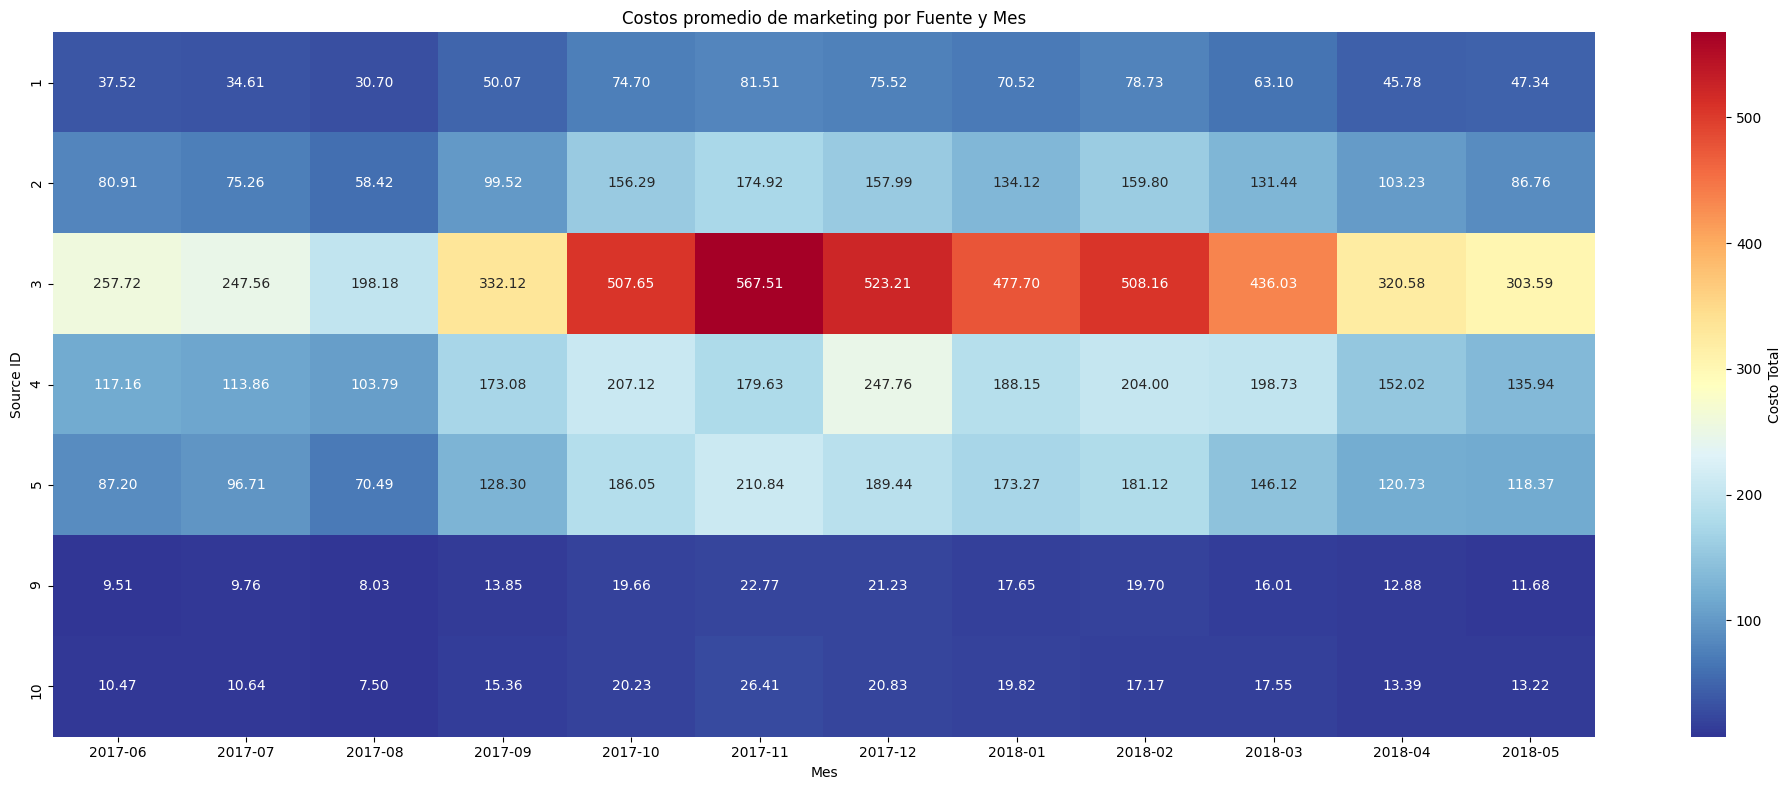

In [66]:
#Crear un heatmap
plt.figure(figsize=(20, 8))
sns.heatmap(pivot_costs, 
            annot=True,          
            fmt='.2f',           
            cmap='RdYlBu_r',       
            cbar_kws={'label': 'Costo Total'})

plt.title('Costos promedio de marketing por Fuente y Mes')
plt.xlabel('Mes')
plt.ylabel('Source ID')
plt.tight_layout()
plt.show()

+ De acuerdo al gráfico anterior, se puede observar que la fuente con ID correspondiente a 3 fue la que tuvo mayores costos especialmente en el período Octubre 2017 a Marzo 2018.
+ El costo más elevado en promedio fue de 567.51 en Noviembre 2017 para el source ID 3.
+ Otras fuentes de adquisición medianamente costosas correspondieron al source ID 2, 4 y 5 que coinciden con el mismo período de Octubre 2017 a Marzo 2018.
+ Las fuentes de adquisición menos costosas correspondieron a los source ID 9 y 10.
+ El costo mínimo correspondió al source ID 10 durante el mes de Agosto 2017 con un promedio de 7.50

**Gasto a lo largo del tiempo (por mes):**

In [67]:
#Agrupar por mes y obtener costo total
costs_per_month= costs.groupby("month")["costs"].sum().reset_index()
costs_per_month.columns= ("month", "total_cost")
costs_per_month

,month,total_cost
0,2017-06,18015.00
1,2017-07,18240.59
2,2017-08,14790.54
3,2017-09,24368.91
4,2017-10,36322.88
5,2017-11,37907.88
6,2017-12,38315.35
7,2018-01,33518.52
8,2018-02,32723.03
9,2018-03,30415.27


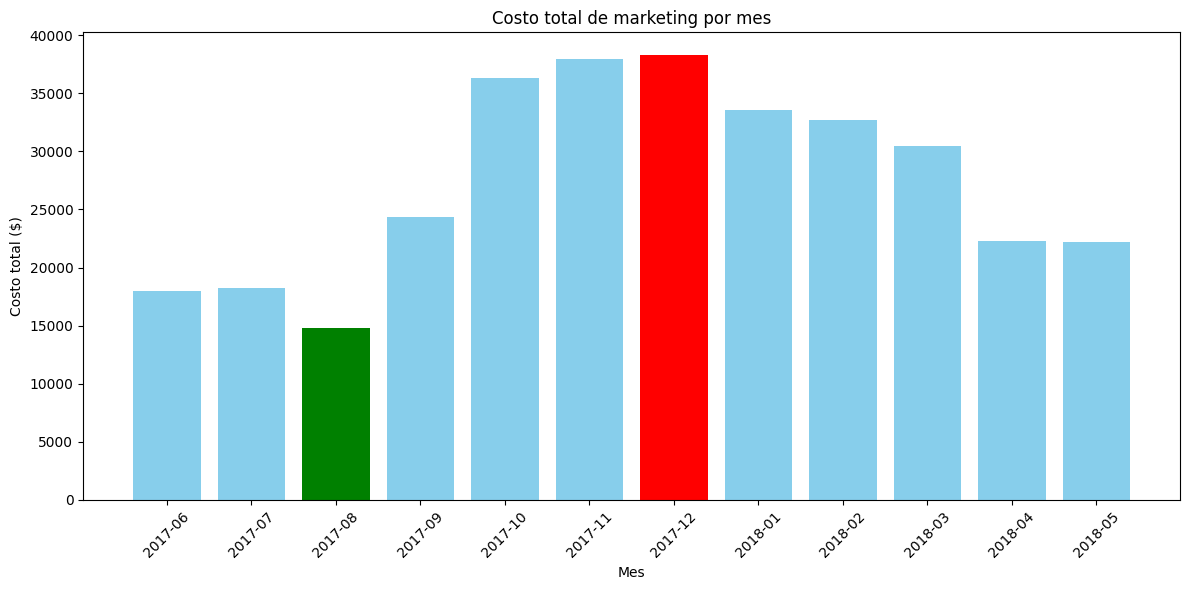

In [68]:
#Crear gráfico de barras para detectar meses con mayor y menor gasto en marketing

costs_per_month["month"] = costs_per_month["month"].astype(str)

# Identificar máximo y mínimo
max_value = costs_per_month["total_cost"].max()
min_value = costs_per_month["total_cost"].min()

# Colores: rojo para máx, verde para mín, azul para el resto
colors = []
for value in costs_per_month["total_cost"]:
    if value == max_value:
        colors.append("red")
    elif value == min_value:
        colors.append("green")
    else:
        colors.append("skyblue")

# Graficar
plt.figure(figsize=(12, 6))
bars = plt.bar(costs_per_month["month"], costs_per_month["total_cost"], color=colors)

# Configuración de ejes y título
plt.xticks(rotation=45)
plt.title("Costo total de marketing por mes")
plt.xlabel("Mes")
plt.ylabel("Costo total ($)")
plt.tight_layout()
plt.show()

+ El mes de Diciembre 2017 fue donde se reportaron mayores costos de marketing, seguidos de los meses Noviembre y Octubre 2017.
+ El mes con menores costos reportados fue en Agosto 2017.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Muy buen desglose de los costos de marketing por fuente y por mes, complementado con visualizaciones claras. La interpretación de máximos y mínimos es precisa y aporta valor al análisis. </div>


**2.¿Cuál fue el costo de adquisición de clientes (CAC) de cada una de las fuentes?**

In [69]:
#Unir la tabla visits y orders mediante uid
customers_per_source = orders.merge(visits[["uid", "source_id"]].drop_duplicates(), on='uid', how='inner')
        
customers_per_source.head()

,buy_ts,revenue,uid,buy_date,buy_day,buy_month,buy_year,buy_month_year,source_id
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,1,6,2017,2017-06,1
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,1,6,2017,2017-06,2
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,1,6,2017,2017-06,2
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,1,6,2017,2017-06,2
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,1,6,2017,2017-06,3


In [70]:
#Agrupar por source_id y usuarios únicos 
source_uid= customers_per_source.groupby(["buy_month_year","source_id"])["uid"].nunique().reset_index()
source_uid.columns= ('month','source_id','n_new_customers')

source_uid.head()

,month,source_id,n_new_customers
0,2017-06,1,401
1,2017-06,2,457
2,2017-06,3,874
3,2017-06,4,644
4,2017-06,5,571


**Gasto de marketing por fuente**

In [71]:
marketing_source = costs.groupby(['month', 'source_id'])['costs'].sum().reset_index()
marketing_source.head()

,month,source_id,costs
0,2017-06,1,1125.61
1,2017-06,2,2427.38
2,2017-06,3,7731.65
3,2017-06,4,3514.80
4,2017-06,5,2616.12


**Cálculo de CAC por fuente y mes**

In [72]:
# Combinar clientes y gastos
cac_source = source_uid.merge(marketing_source, on=['month', 'source_id'])

# CAC = Costo / Clientes nuevos
cac_source['CAC'] = (cac_source['costs'] / cac_source['n_new_customers']).round(2)
cac_source.head()

,month,source_id,n_new_customers,costs,CAC
0,2017-06,1,401,1125.61,2.81
1,2017-06,2,457,2427.38,5.31
2,2017-06,3,874,7731.65,8.85
3,2017-06,4,644,3514.80,5.46
4,2017-06,5,571,2616.12,4.58


In [73]:
#Crear tabla pivote
cac_pivot= cac_source.pivot(index= "month",
                           columns= "source_id",
                           values= "CAC")
cac_pivot

source_id,1,2,3,4,5,9,10
month,,,,,,,
2017-06,2.81,5.31,8.85,5.46,4.58,1.55,2.62
2017-07,2.46,5.00,10.19,4.58,4.76,1.83,4.34
2017-08,2.82,5.33,11.15,5.77,4.28,1.38,3.75
2017-09,2.43,4.67,8.83,5.21,4.07,1.59,3.78
2017-10,2.37,4.62,8.68,3.43,3.88,1.33,2.26
2017-11,2.11,4.36,8.85,2.66,4.84,1.32,3.85
2017-12,1.99,4.29,7.86,3.39,4.31,1.47,4.14
2018-01,2.48,4.79,9.27,3.40,4.63,1.63,4.27
2018-02,2.46,4.82,8.36,3.14,4.03,1.66,2.32


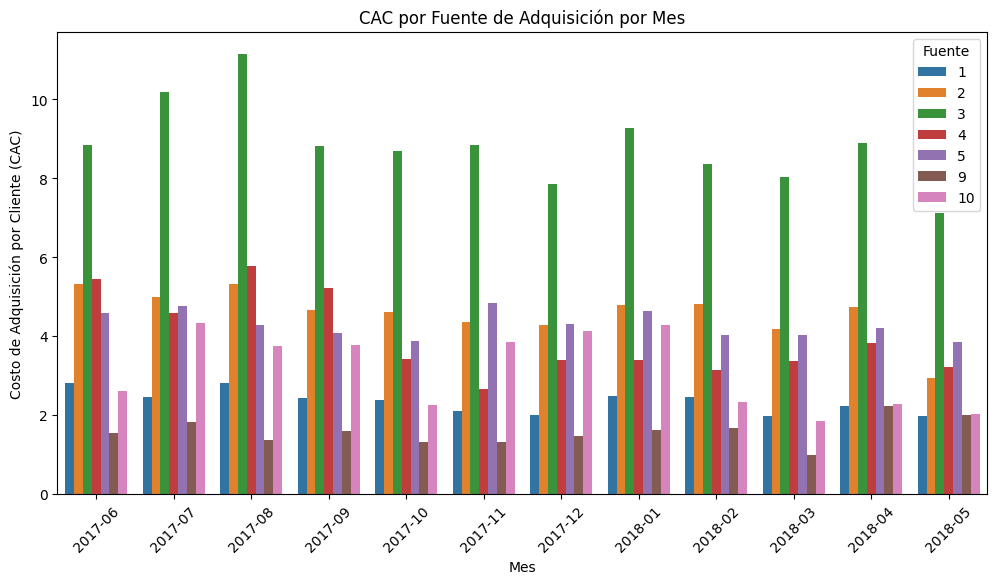

In [74]:
#Gráfico de barras
cac_source['month_str'] = cac_source['month'].astype(str)

plt.figure(figsize=(12,6))
sns.barplot(data=cac_source,
    x='month_str',
    y='CAC',
    hue='source_id'
)

plt.title('CAC por Fuente de Adquisición por Mes')
plt.ylabel('Costo de Adquisición por Cliente (CAC)')
plt.xlabel('Mes')
plt.legend(title='Fuente')
plt.xticks(rotation=45)
plt.show()

De acuerdo al cálculo de CAC por fuente se puede concluir que:

+ La fuente 3 fue en definitiva la que presentó mayor CAC a lo largo de todo el año, especialmente en los meses de Julio y Agosto 2017. 

+ La fuente 9 fue la que presentó menor CAC en el mismo período analizado. Su valor más bajo se alcanzó durante el mes Marzo 2018.

+ En cuanto a las fuentes 2, 4 y 5, el CAC se mantuvo costante y en valores similares a lo largo de todo el año.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Excelente cálculo del CAC por fuente y mes. La comparación entre canales está bien detallada y las conclusiones resaltan con claridad las diferencias de eficiencia en adquisición. </div>


**3. ¿Cuán rentables eran las inversiones?:Análisis ROMI por mes y fuente de adquisición**

1. Revenue por fuente de adquisición:

In [75]:
#Unir tabla visits con orders mediante uid y source_id
orders_with_source= orders.merge(visits[["uid", "source_id"]], 
                                 on= "uid",
                                 how= "left")

orders_with_source.sample(5)

,buy_ts,revenue,uid,buy_date,buy_day,buy_month,buy_year,buy_month_year,source_id
565820,2018-03-01 11:51:00,4.52,13975932056717210136,2018-03-01,1,3,2018,2018-03,4
543430,2018-02-22 23:15:00,3.67,3963367130094376110,2018-02-22,22,2,2018,2018-02,4
619434,2018-03-21 13:49:00,0.92,11920452646463905188,2018-03-21,21,3,2018,2018-03,4
56710,2017-07-26 12:02:00,3.30,345670729557782714,2017-07-26,26,7,2017,2017-07,5
222403,2017-10-27 02:36:00,10.39,15239488130214522285,2017-10-27,27,10,2017,2017-10,3


In [76]:
#Cálculo de revenue por fuente
revenue_source= orders_with_source.groupby(["buy_month_year", "source_id"])["revenue"].sum().reset_index()
revenue_source.columns= ("month", "source_id", "total_revenue")
revenue_source

,month,source_id,total_revenue
0,2017-06,1,51524.95
1,2017-06,2,49626.01
2,2017-06,3,7467.82
3,2017-06,4,13644.17
4,2017-06,5,23407.59
...,...,...,...
81,2018-05,4,25161.50
82,2018-05,5,55584.00
83,2018-05,9,2539.14
84,2018-05,10,2576.94


In [77]:
#Gastos de marketing por fuente y mes
marketing_source.head()

,month,source_id,costs
0,2017-06,1,1125.61
1,2017-06,2,2427.38
2,2017-06,3,7731.65
3,2017-06,4,3514.80
4,2017-06,5,2616.12


In [78]:
#Calcular ROMI
romi = revenue_source.merge(marketing_source, on=["month", "source_id"])
romi["romi"] = ((romi["total_revenue"] - romi["costs"]) / romi["costs"]).round(2)
romi["romi_pct"] = romi["romi"]*100
romi[["month", "source_id", "total_revenue", "costs", "romi", "romi_pct"]].head()

,month,source_id,total_revenue,costs,romi,romi_pct
0,2017-06,1,51524.95,1125.61,44.78,4478.0
1,2017-06,2,49626.01,2427.38,19.44,1944.0
2,2017-06,3,7467.82,7731.65,-0.03,-3.0
3,2017-06,4,13644.17,3514.80,2.88,288.0
4,2017-06,5,23407.59,2616.12,7.95,795.0


In [79]:
#Tabla pivote
romi_pivot= romi.pivot(index= "month",
                      columns= "source_id",
                      values= "romi_pct")

romi_pivot

source_id,1,2,3,4,5,9,10
month,,,,,,,
2017-06,4478.0,1944.0,-3.0,288.0,795.0,433.0,196.0
2017-07,10312.0,2615.0,52.0,491.0,1372.0,488.0,53.0
2017-08,8964.0,2928.0,63.0,430.0,1760.0,759.0,169.0
2017-09,18496.0,7929.0,220.0,1107.0,3046.0,658.0,45.0
2017-10,7978.0,5726.0,82.0,875.0,1998.0,635.0,117.0
2017-11,8134.0,2502.0,57.0,836.0,1105.0,650.0,105.0
2017-12,11883.0,13925.0,281.0,973.0,5483.0,594.0,40.0
2018-01,6237.0,5129.0,43.0,545.0,1520.0,277.0,-12.0
2018-02,8760.0,5882.0,89.0,758.0,2350.0,407.0,254.0


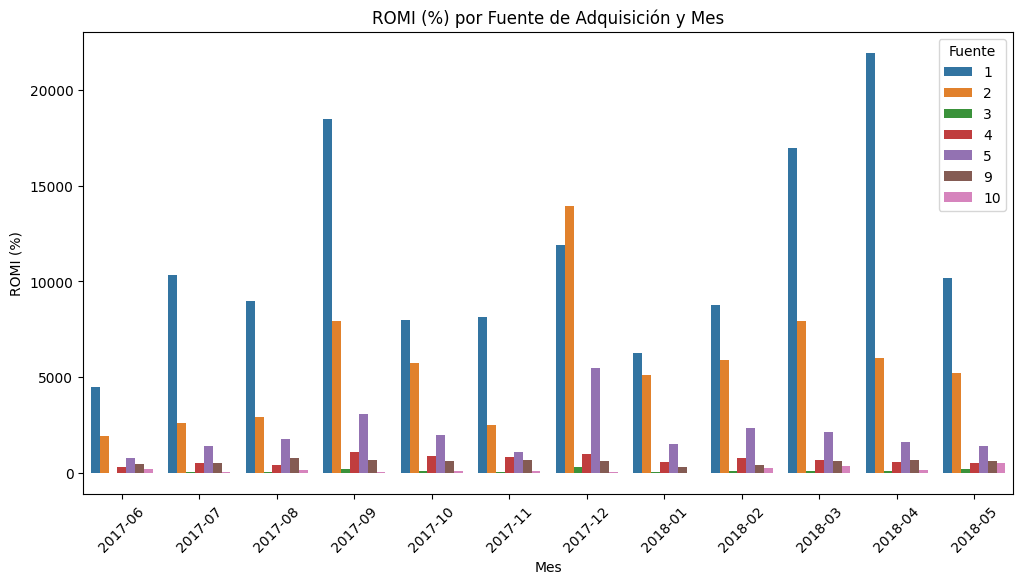

In [80]:
#Gráfico de barras 
plt.figure(figsize=(12,6))
sns.barplot(
    data=romi,
    x='month',
    y='romi_pct',
    hue='source_id'
)

plt.title('ROMI (%) por Fuente de Adquisición y Mes')
plt.ylabel('ROMI (%)')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.legend(title='Fuente')
plt.show()

De acuerdo al cálculo de ROMI, se puede concluir que:

+ La fuente 1 fue la que tuvo mayor retorno de inversión, muy por encima de las otras, especialemente durante los meses de Marzo-Abril 2018 y Septiembre 2017.
+ En segundo lugar se encuentra la fuente 2 con un ROMI mayor en los meses de Septiembre y Diciembre 2017.
+ Las fuentes 3 y 10 fueron las que presentaron menor ROMI a lo largo del año.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Muy buen cálculo e interpretación del ROMI. Lograste identificar con claridad las fuentes más rentables y las menos eficientes, destacando correctamente los períodos de mayor retorno. </div>


## Paso 3: Conclusiones

**Conclusión General**

El análisis de datos de la plataforma Showz revela patrones críticos de comportamiento del usuario y oportunidades significativas de optimización. Con una tasa de no conversión del 84%, existe un enorme potencial de mejora en la experiencia del usuario y las estrategias de marketing. 

Los hallazgos evidencian 4 aspectos fundamentales:

+ **Estacionalidad marcada** con picos en Octubre-Diciembre. Se pueden maximizar estos períodos de alta demanda.
  
+ **Baja retención diaria** (sticky factors de 16% semanal y 4% mensual). Reflejan la naturaleza estacional del negocio de entretenimiento, donde la frecuencia de compra es naturalmente baja pero el valor por transacción puede ser alto.

+ **Comportamientos de compra inmediatos** donde el 11.5% de usuarios se convierten el mismo día de su primera visita.

+ **Comportamiento por dispositivo**: Aunque desktop domina en volumen (77% de usuarios), el ticket promedio es superior en touch (10.57 vs 9.04). Esto sugiere que los usuarios móviles son más decididos y dispuestos a pagar más, posiblemente por la inmediatez del dispositivo.

+ **Cohortes de Alto Valor Identificadas:** Las cohortes de septiembre-diciembre 2017 no solo generaron mayor LTV sino que mantuvieron patrones de compra sostenidos, alcanzando LTV promedio por usuario significativamente superior al promedio general.

## Recomendaciones Estratégicas de Marketing

### 1. Optimización de la Conversión Inmediata
**Problema identificado**: 84% de usuarios no convierten y el tiempo promedio de sesión es de solo 60 segundos.

**Recomendaciones**:

- Crear un **proceso de checkout simplificado** para acelerar la intención de compra inmediata.
- Establecer **programas de descuentos progresivos** (5% primer minuto, 10% primeros 5 minutos) para incentivar decisiones rápidas.

### 2. Estrategia Estacional Inteligente
**Problema identificado**: Caída significativa en agosto (11,631 visitas vs +30,000 en nov-dic).

**Recomendaciones**:

- **Marketing contra-estacional**: Crear eventos especiales de verano con descuentos agresivos (20-30%) para mantener flujo de caja.
- **Diversificación de contenido**: Promover otros eventos o experiencias exclusivas durante meses bajos.

### 3. Optimización por Dispositivo
**Problema identificado**: Mayor preferencia por desktop pero mayor ticket promedio en mobile.

**Recomendaciones**:

- **Priorizar experiencia mobile** para mejorar conversión en dispositivos touch.

### 4. Reactivación de Usuarios No Convertidos
**Problema identificado**: 191,646 usuarios visitaron pero no compraron (84% del total).

**Recomendaciones**:

- **Retargeting personalizado**: Mostrar anuncios con eventos similares a los consultados originalmente.

### 5. Maximización del Valor de Cohortes Rentables
**Problema identificado**: Cohortes sep-dic 2017 generaron mayor LTV pero menor volumen en algunas.

**Recomendaciones**:

- **Identificar características de usuarios** de cohortes exitosas para targeting futuro.
- **Fidelización**: Ofrecer beneficios exclusivos a usuarios de cohortes valiosas.

### 6. Optimización de Canales de Adquisición
**Problema identificado**: Fuente 3 tiene alto CAC pero bajo ROMI; Fuente 1 tiene excelente ROMI.

**Recomendaciones**:

- **Redistribución presupuestaria**: Incrementar inversión en Fuente 1 (alto ROMI) y reducir gradualmente Fuente 3.
- **Optimización de Fuente 3** para reducir CAC.
- **Testing continuo**: Implementar testing mensual en todas las fuentes para optimización constante

### 7. Estrategia de Retención a Largo Plazo
**Problema identificado**: Baja retención diaria y comportamiento ocasional de compra.

**Recomendaciones**:

- **Programa de puntos**: Sistema de recompensas que incentive compras regulares y referidos.

## Métricas Clave a Monitorear

- **Tasa de conversión mensual** (objetivo: reducir tasa de no-conversión)
- **Tiempo promedio de sesión** (objetivo: incrementar el tiempo a mayor de 60 segundos)
- **LTV por cohorte** (mantener tendencia creciente identificada)
- **ROMI por canal** (optimizar canales con ROMI <200%)
- **Sticky factor** (objetivo: incrementar WAU y MAU)

## Comentario general del revisor 

# Comentario General del Revisor

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a> 
    
¡Felicidades! Tu proyecto está **aprobado**. Has demostrado un excelente manejo del flujo completo de análisis, desde la preparación de datos hasta la interpretación de métricas y la generación de conclusiones estratégicas.  

#### Puntos Positivos:

* **Procesamiento de datos:** Correcta limpieza, estandarización y transformación de tipos, lo que permitió asegurar la calidad de la información.
* **Visualización y análisis gráfico:** Uso adecuado de gráficos para ilustrar patrones de visitas, conversiones, cohortes y canales de marketing, siempre acompañados de interpretaciones claras.
* **Ingeniería de características y métricas:** Creación precisa de indicadores clave (DAU, WAU, MAU, sticky factor, LTV, CAC, ROMI), aplicados con rigor técnico y explicados en un lenguaje comprensible.
* **Conexión con el negocio:** Las recomendaciones son accionables y bien alineadas con los hallazgos, mostrando capacidad para transformar datos en estrategias útiles.

Tu análisis no solo cumple con todos los requisitos del brief, sino que también aporta un enfoque crítico y estratégico al contexto de negocio. Un proyecto integral y bien logrado. </div>
